<a href="https://colab.research.google.com/github/pedroemilio17/Machine_learning/blob/main/3_EDA_DOCUMENTADA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

O objetivo desta etapa é compreender a estrutura e as principais características
do conjunto de dados UNSW-NB15.
Serão analisadas a estrutura do dataset, as estatísticas descritivas, a qualidade
dos dados, a distribuição dos tipos de tráfego e as categorias de ataques,
buscando identificar padrões relevantes para as etapas posteriores de agrupamento.

# Sumário

1. **Carregamento do Dataset**
2. **Estrutura do Dataset**
3. **Estatísticas Descritivas**
4. **Qualidade dos Dados**
5. **Distribuição dos Tipos de Tráfego**
   - 5.1 Tráfego Normal × Ataques
   - 5.2 Categorias de Ataques
6. **Análise das Características do Tráfego**
   - 6.1 Protocolos de Rede
   - 6.2 Serviços de Rede
   - 6.3 Estados das Conexões
   - 6.4 Principais Variáveis Numéricas
7. **Análise de Distribuição e Outliers**
8. **Análise de Correlação**
9. **Comparação entre Tráfego Normal e Ataques**
10. **Principais Padrões Identificados**
11. **Conclusões da Análise Exploratória**

## 1. Carregamento do dataset



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

from kagglehub import KaggleDatasetAdapter

# Define o nome do arquivo parquet que deseja carregar
file_path = "UNSW_NB15_training-set.parquet"

# Carrega o dataset
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "dhoogla/unswnb15",
    file_path
)

print("First 5 records:")
display(df.head())
# Install dependencies as needed:
# %pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Defina o nome do arquivo parquet que deseja carregar
file_path = "UNSW_NB15_training-set.parquet"

# Carrega a versão mais recente usando dataset_load
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "dhoogla/unswnb15",
  file_path
)

print("First 5 records:")
display(df.head())

100%|██████████| 9.17M/9.17M [00:00<00:00, 101MB/s]


First 5 records:


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


Using Colab cache for faster access to the 'unswnb15' dataset.
First 5 records:


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


## 2. Estrutura do dataset

Inicialmente, são verificadas as dimensões do conjunto de dados, os nomes
das variáveis e os tipos de dados presentes.

In [3]:
print("Quantidade de registros:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

print("\nColunas do dataset:")
print(df.columns.tolist())

Quantidade de registros: 175341
Quantidade de colunas: 36

Colunas do dataset:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit               175341 non-null

## 3. Estatísticas descritivas

As estatísticas descritivas permitem analisar características como média,
desvio padrão, valores mínimos, máximos e quartis das variáveis numéricas.
Essa análise auxilia na identificação de diferenças de escala, dispersão
e possíveis valores extremos.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
dur,175341.0,1.359389e+00,6.483313e+00,0.0,0.000008,0.001582,6.680690e-01,5.999999e+01
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07
rate,175341.0,9.540618e+04,1.654177e+05,0.0,32.786140,3225.806641,1.250000e+05,1.000000e+06
sload,175341.0,7.345403e+07,1.883701e+08,0.0,13053.338867,879674.750000,8.888889e+07,5.988000e+09
dload,175341.0,6.712055e+05,2.423637e+06,0.0,0.000000,1447.022705,2.784487e+04,2.242273e+07
sloss,175341.0,4.953000e+00,6.600506e+01,0.0,0.000000,0.000000,3.000000e+00,4.803000e+03
dloss,175341.0,6.948010e+00,5.273300e+01,0.0,0.000000,0.000000,2.000000e+00,5.484000e+03


## 4. Qualidade dos dados

Nesta etapa são verificados valores ausentes e registros duplicados,
permitindo identificar possíveis problemas que deverão ser considerados
posteriormente durante o tratamento dos dados.

In [6]:
print("Valores ausentes:", df.isnull().sum().sum())
print("Registros duplicados:", df.duplicated().sum())

Valores ausentes: 0
Registros duplicados: 78519


## 5. Distribuição dos tipos de tráfego

Embora as variáveis `label` e `attack_cat` não sejam utilizadas para formar
os agrupamentos, elas são analisadas durante a EDA para compreender a
composição do dataset e posteriormente poderão auxiliar na avaliação dos
clusters encontrados.

In [7]:
print(df['label'].value_counts())

print("\nCategorias:")
print(df['attack_cat'].value_counts())

label
1    119341
0     56000
Name: count, dtype: int64

Categorias:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


Distribuição percentual:
label
0    31.94
1    68.06
Name: proportion, dtype: float64


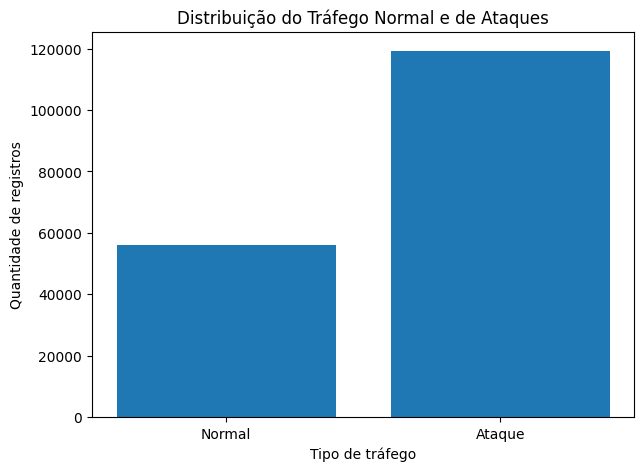

In [8]:
import matplotlib.pyplot as plt

# Contagem de tráfego normal e ataques
contagem_label = df['label'].value_counts().sort_index()

# Cálculo das porcentagens
porcentagem_label = df['label'].value_counts(normalize=True).sort_index() * 100

print("Distribuição percentual:")
print(porcentagem_label.round(2))

# Gráfico
plt.figure(figsize=(7, 5))

plt.bar(['Normal', 'Ataque'], contagem_label.values)

plt.title('Distribuição do Tráfego Normal e de Ataques')
plt.xlabel('Tipo de tráfego')
plt.ylabel('Quantidade de registros')

plt.show()

### Interpretação

A análise mostra que o conjunto de dados possui uma maior quantidade de
registros relacionados a ataques do que de tráfego normal. Aproximadamente
68% dos registros representam ataques, enquanto cerca de 32% correspondem
a tráfego normal.

Essa diferença indica um desbalanceamento entre os dois tipos de tráfego.
Embora a variável `label` não seja utilizada diretamente na formação dos
clusters, ela poderá ser utilizada posteriormente para analisar a composição
dos grupos encontrados pelos algoritmos de agrupamento.


Quantidade por categoria:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


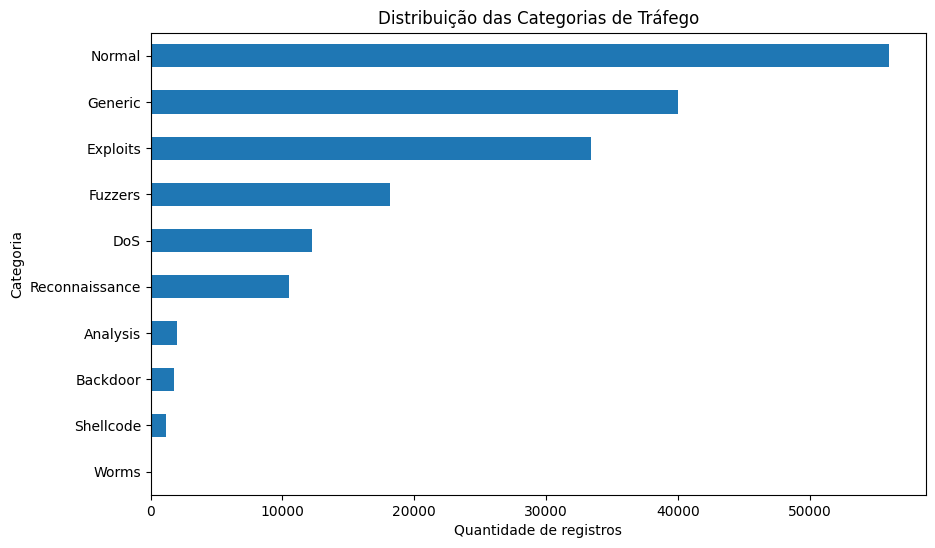

In [9]:
# Quantidade de registros por categoria
contagem_categorias = df['attack_cat'].value_counts().sort_values()

print("Quantidade por categoria:")
print(df['attack_cat'].value_counts())

# Gráfico
plt.figure(figsize=(10, 6))

contagem_categorias.plot(kind='barh')

plt.title('Distribuição das Categorias de Tráfego')
plt.xlabel('Quantidade de registros')
plt.ylabel('Categoria')

plt.show()

### Interpretação

A distribuição das categorias mostra que os diferentes tipos de ataques
não possuem a mesma quantidade de registros. Algumas categorias apresentam
uma representação significativamente maior, enquanto outras possuem
poucas ocorrências.

Esse comportamento demonstra que existe desbalanceamento entre as categorias
de ataques. Essa característica deverá ser considerada na interpretação dos
clusters, pois padrões associados a categorias com poucos registros podem ser
mais difíceis de identificar como grupos separados.

## 6. Análise das Características do Tráfego

Nesta seção são analisadas algumas das principais características das
conexões presentes no dataset, buscando compreender quais protocolos,
serviços e estados de conexão aparecem com maior frequência.

Essas informações ajudam a identificar padrões gerais de comportamento
antes da aplicação dos algoritmos de agrupamento.

Quantidade de protocolos diferentes: 133

10 protocolos mais frequentes:


,count
proto,
tcp,79946
udp,63283
unas,12084
arp,2859
ospf,2595
sctp,1150
any,300
gre,225
swipe,201


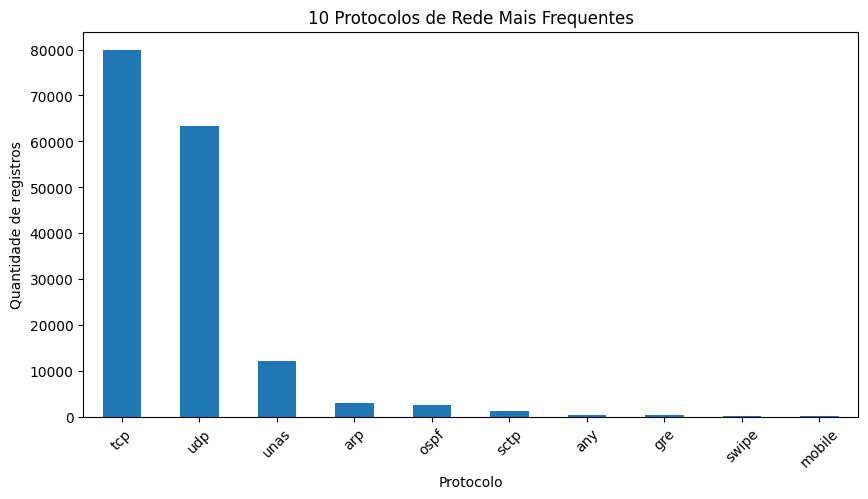

In [10]:
#6.1
# Quantidade de protocolos diferentes
print("Quantidade de protocolos diferentes:", df['proto'].nunique())

# 10 protocolos mais frequentes
protocolos = df['proto'].value_counts().head(10)

print("\n10 protocolos mais frequentes:")
display(protocolos)

# Gráfico
plt.figure(figsize=(10, 5))

protocolos.plot(kind='bar')

plt.title('10 Protocolos de Rede Mais Frequentes')
plt.xlabel('Protocolo')
plt.ylabel('Quantidade de registros')
plt.xticks(rotation=45)

plt.show()

### Interpretação

Foram identificados 133 protocolos diferentes no conjunto de dados. Entretanto,
a distribuição apresenta forte concentração em poucos protocolos.

O protocolo TCP é o mais frequente, com 79.946 registros, seguido pelo UDP,
com 63.283 registros. O protocolo UNAS aparece em terceiro lugar, com 12.084
registros. Os demais protocolos apresentam frequências consideravelmente menores.

Esse resultado demonstra que o tráfego analisado não está distribuído de forma
uniforme entre os protocolos. TCP e UDP representam grande parte das comunicações
presentes no dataset, enquanto diversos outros protocolos possuem baixa
representatividade.

Essa diferença poderá ser relevante para a formação e interpretação dos
agrupamentos, já que o protocolo utilizado constitui uma característica
importante do comportamento de uma conexão de rede.

Quantidade de serviços diferentes: 13

Distribuição dos serviços:


,count
service,
-,94168
dns,47294
http,18724
smtp,5058
ftp-data,3995
ftp,3428
ssh,1302
pop3,1105
dhcp,94


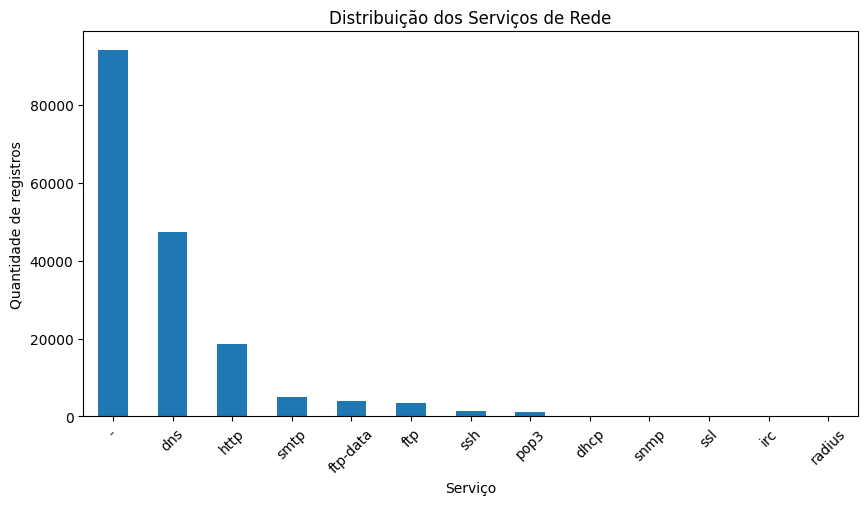

In [11]:
#6.2
# Quantidade de serviços diferentes
print("Quantidade de serviços diferentes:", df['service'].nunique())

# Frequência dos serviços
servicos = df['service'].value_counts()

print("\nDistribuição dos serviços:")
display(servicos)

# Gráfico
plt.figure(figsize=(10, 5))

servicos.plot(kind='bar')

plt.title('Distribuição dos Serviços de Rede')
plt.xlabel('Serviço')
plt.ylabel('Quantidade de registros')
plt.xticks(rotation=45)

plt.show()

### Interpretação

Foram identificadas 13 categorias diferentes na variável `service`. A categoria
mais frequente é representada por "-", com 94.168 registros, indicando conexões
em que não há um serviço específico identificado no campo.

Entre os serviços identificados, o DNS é o mais frequente, com 47.294 registros,
seguido pelo HTTP, com 18.724 registros. Serviços como SMTP, FTP-DATA e FTP
aparecem em quantidades menores, enquanto DHCP, SNMP, SSL, IRC e RADIUS possuem
baixa representatividade no conjunto de dados.

A distribuição mostra uma forte concentração em poucas categorias, especialmente
nos registros sem serviço identificado, DNS e HTTP. Essa característica poderá
ser relevante para a formação dos agrupamentos, pois o serviço associado à
conexão pode ajudar a diferenciar diferentes padrões de tráfego.

Quantidade de estados diferentes: 9

Distribuição dos estados:


,count
state,
INT,82275
FIN,77825
CON,13152
REQ,1991
RST,83
ECO,12
PAR,1
URN,1
no,1


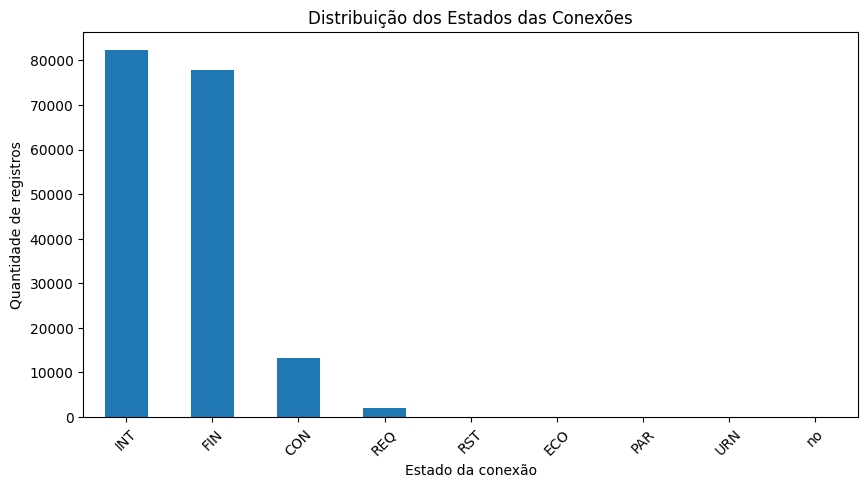

In [12]:
#6.3
# Quantidade de estados diferentes
print("Quantidade de estados diferentes:", df['state'].nunique())

# Frequência dos estados
estados = df['state'].value_counts()

print("\nDistribuição dos estados:")
display(estados)

# Gráfico
plt.figure(figsize=(10, 5))

estados.plot(kind='bar')

plt.title('Distribuição dos Estados das Conexões')
plt.xlabel('Estado da conexão')
plt.ylabel('Quantidade de registros')
plt.xticks(rotation=45)

plt.show()

### Interpretação

Foram identificados 9 estados diferentes nas conexões de rede. A distribuição
apresenta forte concentração nos estados INT e FIN, com 82.275 e 77.825
registros, respectivamente. O estado CON aparece em seguida, com 13.152
registros, enquanto REQ possui 1.981 ocorrências.

Os demais estados apresentam frequência muito baixa, chegando a apenas uma
ocorrência em alguns casos. Dessa forma, observa-se que os estados das conexões
não estão distribuídos de maneira uniforme no conjunto de dados.

Essa concentração poderá influenciar a formação dos agrupamentos, pois os
estados mais frequentes possuem maior representação no dataset, enquanto
comportamentos associados aos estados menos frequentes poderão aparecer como
grupos pequenos ou observações atípicas.

### 6.4 Principais Variáveis Numéricas

Além das características categóricas, o dataset possui diversas variáveis
numéricas que descrevem o comportamento das conexões.

Nesta etapa serão analisadas algumas das principais características relacionadas
à duração das conexões, quantidade de pacotes, volume de dados e taxa de
transmissão. O objetivo é compreender suas distribuições, diferenças de escala
e possíveis valores extremos.

In [13]:
# Principais variáveis numéricas relacionadas ao tráfego
variaveis_numericas = [
    'dur',
    'spkts',
    'dpkts',
    'sbytes',
    'dbytes',
    'rate',
    'sload',
    'dload'
]

# Estatísticas descritivas
estatisticas_numericas = df[variaveis_numericas].describe().T

display(estatisticas_numericas)

,count,mean,std,min,25%,50%,75%,max
dur,175341.0,1.359389e+00,6.483313e+00,0.0,0.000008,0.001582,6.680690e-01,5.999999e+01
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07
rate,175341.0,9.540618e+04,1.654177e+05,0.0,32.786140,3225.806641,1.250000e+05,1.000000e+06
sload,175341.0,7.345403e+07,1.883701e+08,0.0,13053.338867,879674.750000,8.888889e+07,5.988000e+09
dload,175341.0,6.712055e+05,2.423637e+06,0.0,0.000000,1447.022705,2.784487e+04,2.242273e+07


### Interpretação

As estatísticas descritivas mostram diferenças significativas entre as
distribuições e escalas das variáveis numéricas.

Em diversas características, os valores máximos são muito superiores às
medianas e aos terceiros quartis. Esse comportamento pode ser observado,
por exemplo, nas variáveis relacionadas à quantidade de pacotes, volume
de bytes e carga de transmissão.

Essas diferenças indicam distribuições assimétricas e a presença de valores
extremos. Esse resultado será importante na etapa de tratamento dos dados,
pois algoritmos de agrupamento baseados em distância podem ser fortemente
influenciados por diferenças de escala e valores muito elevados.

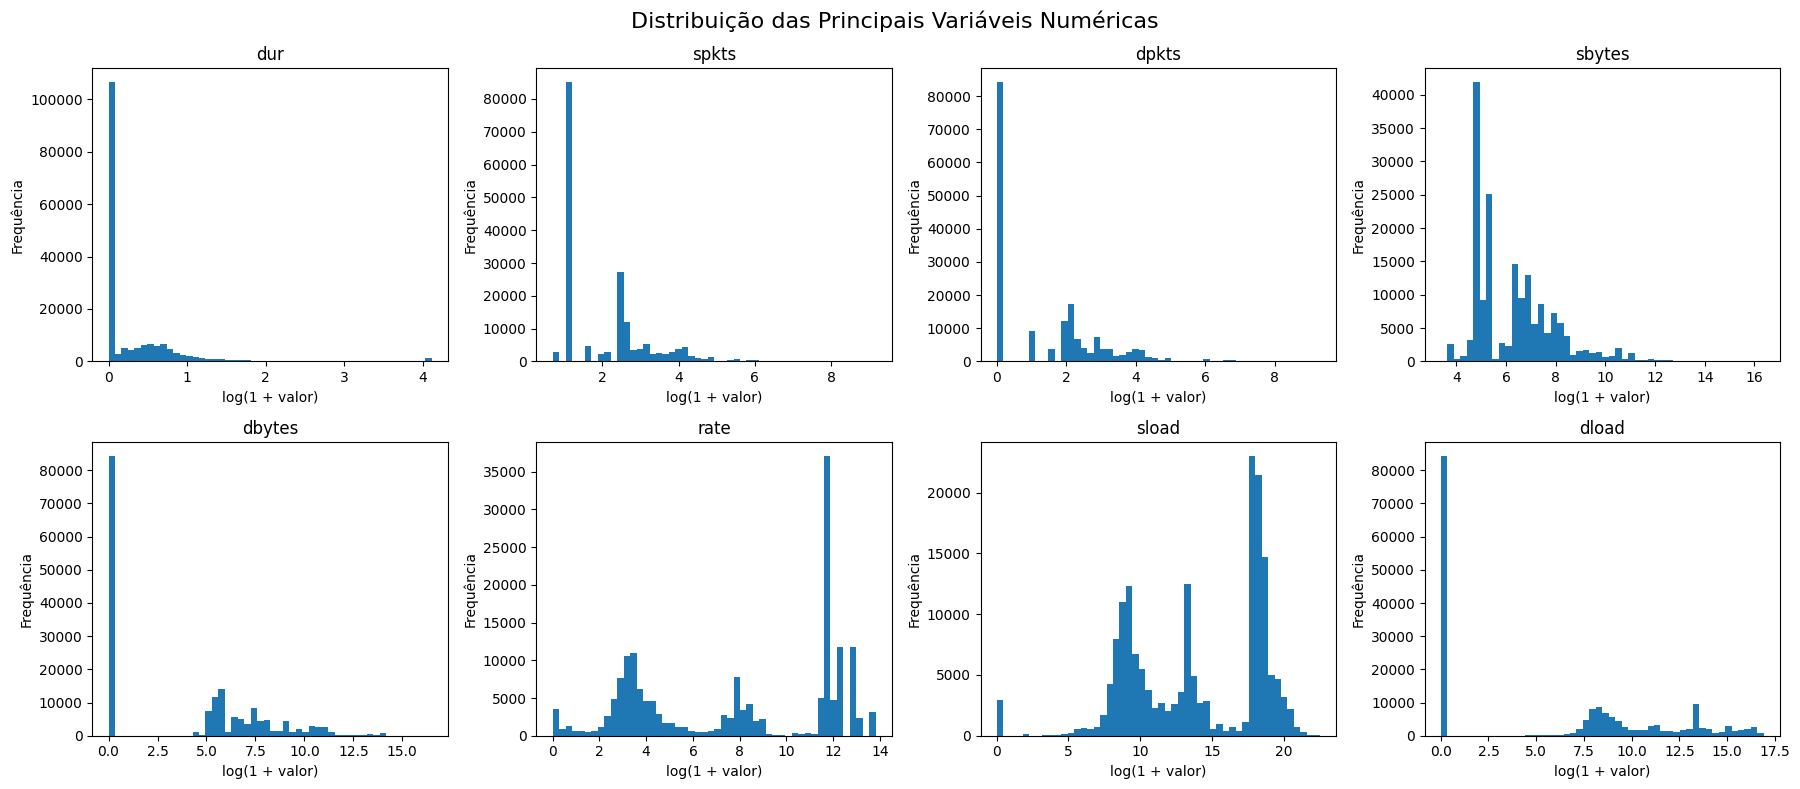

In [14]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

axes = axes.flatten()

for i, coluna in enumerate(variaveis_numericas):

    # log1p permite trabalhar também com valores iguais a zero
    dados_log = np.log1p(df[coluna])

    axes[i].hist(dados_log, bins=50)
    axes[i].set_title(coluna)
    axes[i].set_xlabel('log(1 + valor)')
    axes[i].set_ylabel('Frequência')

plt.suptitle(
    'Distribuição das Principais Variáveis Numéricas',
    fontsize=16
)

plt.tight_layout()

plt.show()

### Interpretação

As distribuições das principais variáveis numéricas apresentam forte assimetria,
mesmo após a utilização da transformação logarítmica para facilitar a
visualização.

As variáveis `dur`, `spkts`, `dpkts`, `dbytes` e `dload` apresentam grande
concentração de registros em valores baixos, acompanhada por grupos menores
de observações com valores mais elevados.

As variáveis `sbytes`, `rate` e `sload` apresentam distribuições mais dispersas
e diferentes concentrações ao longo de seus valores, indicando a existência
de diferentes padrões de comportamento no tráfego de rede.

Esses resultados mostram que as características numéricas não seguem uma
distribuição uniforme e possuem diferenças significativas de escala e dispersão.
Essas características deverão ser consideradas na etapa de tratamento dos dados,
principalmente antes da utilização de algoritmos de agrupamento baseados em
distância.

## 7. Análise de Distribuição e Outliers

Nesta etapa são investigados possíveis valores extremos presentes nas principais
variáveis numéricas.

Em dados de tráfego de rede, valores muito elevados não representam
necessariamente erros, pois podem estar associados a comportamentos específicos
das conexões. Portanto, os outliers serão inicialmente identificados e analisados,
sem serem removidos automaticamente.

In [15]:
#7.1
resultado_outliers = []

for coluna in variaveis_numericas:

    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ]

    quantidade = len(outliers)
    percentual = (quantidade / len(df)) * 100

    resultado_outliers.append([
        coluna,
        quantidade,
        percentual
    ])

outliers_df = pd.DataFrame(
    resultado_outliers,
    columns=['Variável', 'Quantidade de Outliers', 'Percentual (%)']
)

outliers_df['Percentual (%)'] = outliers_df['Percentual (%)'].round(2)

display(outliers_df)

,Variável,Quantidade de Outliers,Percentual (%)
0,dur,15741,8.98
1,spkts,24675,14.07
2,dpkts,20830,11.88
3,sbytes,22873,13.04
4,dbytes,28131,16.04
5,rate,17340,9.89
6,sload,13518,7.71
7,dload,38143,21.75


### Interpretação

A análise pelo método IQR identificou valores extremos em todas as variáveis
numéricas avaliadas. A variável `dload` apresentou a maior proporção, com
21,75% dos registros classificados como outliers, seguida por `dbytes`
(16,04%), `spkts` (14,07%) e `sbytes` (13,04%).

As demais variáveis também apresentaram proporções relevantes de valores
extremos, variando entre 7,71% e 11,88%.

Entretanto, esses registros não serão removidos automaticamente. Como o
dataset representa tráfego de rede e o objetivo do projeto envolve a
identificação de diferentes padrões de comportamento, valores extremos podem
representar comunicações legítimas pouco frequentes ou comportamentos
potencialmente anômalos.

Dessa forma, os outliers serão considerados durante a etapa de tratamento
e na escolha das técnicas de normalização e agrupamento.

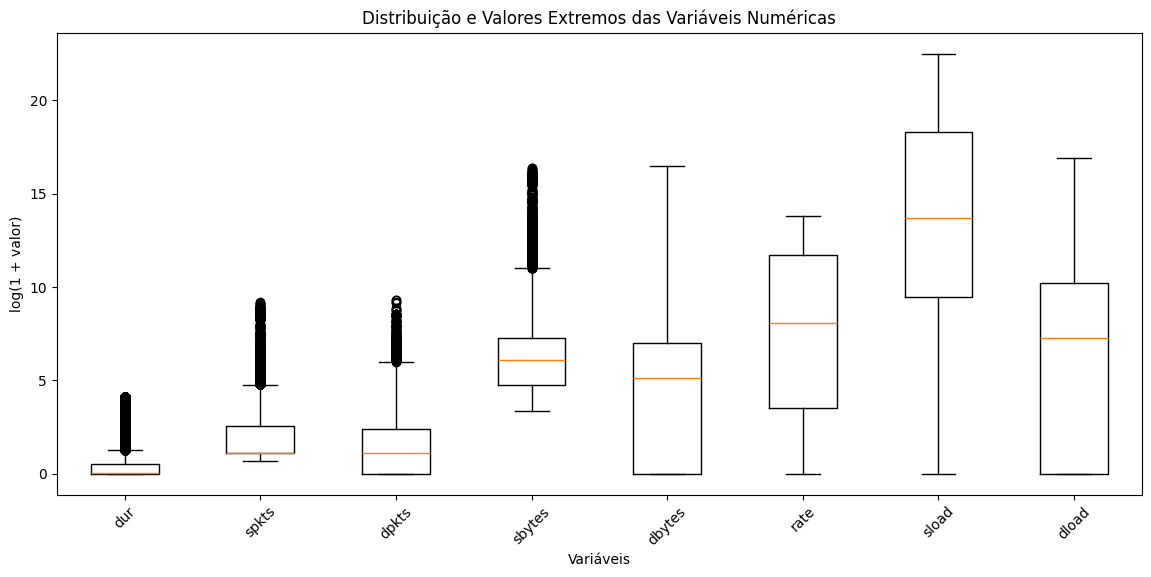

In [16]:
#7.2
# Transformação logarítmica apenas para visualização
dados_log = np.log1p(df[variaveis_numericas])

plt.figure(figsize=(14, 6))

plt.boxplot(
    [dados_log[coluna] for coluna in variaveis_numericas],
    tick_labels=variaveis_numericas,
    showfliers=True
)

plt.title('Distribuição e Valores Extremos das Variáveis Numéricas')
plt.xlabel('Variáveis')
plt.ylabel('log(1 + valor)')
plt.xticks(rotation=45)

plt.show()

### Interpretação

Os boxplots confirmam a presença de valores extremos e diferenças significativas
na dispersão das variáveis numéricas. Mesmo após a transformação logarítmica,
algumas características apresentam observações distantes da maior concentração
dos dados.

Variáveis como `dur`, `spkts`, `dpkts` e `sbytes` apresentam diversos valores
acima dos limites observados nos boxplots. Além disso, `rate`, `sload` e `dload`
possuem ampla dispersão, evidenciando a diversidade dos comportamentos presentes
no tráfego de rede.

Como valores extremos podem representar comportamentos relevantes para a análise
de segurança, eles não serão removidos automaticamente. Na etapa de tratamento,
serão avaliadas estratégias de transformação e escalonamento adequadas antes da
aplicação dos algoritmos de agrupamento.

## 8. Análise de Correlação

A análise de correlação permite investigar a relação entre as variáveis numéricas
do conjunto de dados. O objetivo é identificar características que apresentam
comportamentos semelhantes e compreender melhor as relações existentes entre
diferentes aspectos do tráfego de rede.

Essa análise também poderá auxiliar posteriormente na seleção das variáveis
utilizadas pelos algoritmos de agrupamento.

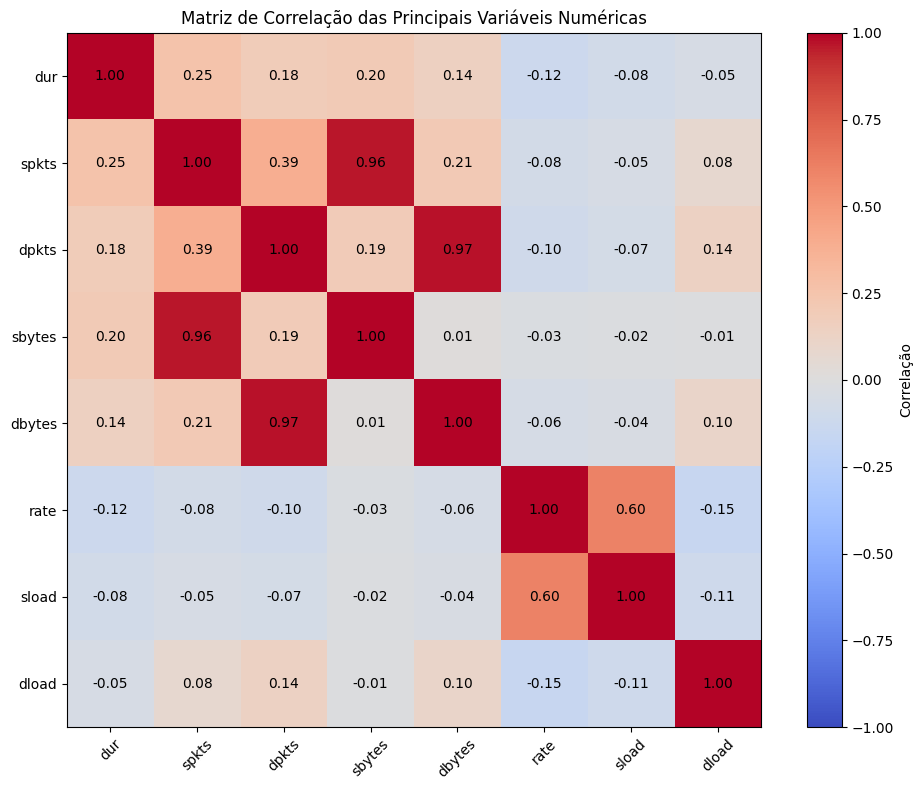

In [17]:
# Calcula a correlação entre as principais variáveis numéricas
correlacao = df[variaveis_numericas].corr()

plt.figure(figsize=(10, 8))

imagem = plt.imshow(
    correlacao,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.colorbar(imagem, label='Correlação')

plt.xticks(
    range(len(variaveis_numericas)),
    variaveis_numericas,
    rotation=45
)

plt.yticks(
    range(len(variaveis_numericas)),
    variaveis_numericas
)

# Valores dentro das células
for i in range(len(variaveis_numericas)):
    for j in range(len(variaveis_numericas)):
        plt.text(
            j, i,
            f'{correlacao.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Matriz de Correlação das Principais Variáveis Numéricas')
plt.tight_layout()
plt.show()

### Interpretação

A matriz de correlação revelou relações importantes entre algumas das
características do tráfego de rede.

A correlação mais elevada foi observada entre `dpkts` e `dbytes`, com valor
de 0,97, indicando uma forte relação positiva entre a quantidade de pacotes
recebidos e o volume de bytes recebidos. Da mesma forma, `spkts` e `sbytes`
apresentaram correlação de 0,96, mostrando uma forte relação entre a quantidade
de pacotes enviados e o volume de bytes enviados.

Também foi identificada uma correlação moderada de 0,60 entre `rate` e `sload`.
As demais relações apresentaram correlações relativamente baixas.

Esses resultados indicam que algumas variáveis carregam informações bastante
semelhantes. Esse aspecto deverá ser considerado posteriormente na seleção e
preparação das características utilizadas pelos algoritmos de agrupamento,
evitando que informações muito correlacionadas exerçam influência excessiva
na formação dos clusters.

## 9. Comparação entre Tráfego Normal e Ataques

Nesta etapa são comparadas algumas características do tráfego normal e dos
registros associados a ataques.

A variável `label` será utilizada apenas para fins de análise e interpretação.
Ela não será utilizada como característica de entrada para os algoritmos de
agrupamento, preservando a natureza não supervisionada do projeto.

In [18]:
comparacao = df.groupby('label')[variaveis_numericas].median().T

comparacao.columns = ['Normal', 'Ataque']

display(comparacao)

,Normal,Ataque
dur,0.038603,9.000000e-06
spkts,12.000000,2.000000e+00
dpkts,10.000000,0.000000e+00
sbytes,1470.000000,2.000000e+02
dbytes,1112.000000,0.000000e+00
rate,1382.256653,1.111111e+05
sload,431327.656250,5.066666e+07
dload,336120.640625,0.000000e+00


### Interpretação

A comparação das medianas evidencia diferenças importantes entre o tráfego
normal e os registros associados a ataques.

O tráfego normal apresenta medianas maiores para quantidade de pacotes enviados
e recebidos (`spkts` e `dpkts`) e para volume de bytes enviados e recebidos
(`sbytes` e `dbytes`). Nos registros de ataque, algumas dessas características
apresentam valores consideravelmente menores, especialmente `dpkts` e `dbytes`,
cujas medianas são iguais a zero.

Por outro lado, os registros associados a ataques apresentam valores medianos
muito superiores para `rate` e `sload`, indicando maior taxa de transmissão
e carga de dados enviados em parte significativa desse tráfego.

Essas diferenças sugerem que as características numéricas possuem potencial
para separar diferentes padrões de comportamento. Esse resultado é especialmente
relevante para o projeto, pois indica que algoritmos de agrupamento poderão
encontrar estruturas relacionadas a diferentes perfis de tráfego mesmo sem
utilizar diretamente os rótulos de ataque.

isso não prova ainda que o clustering conseguirá separar normal de ataque. Mostra que existem diferenças nas características e, portanto, há potencial para encontrarmos grupos distintos.

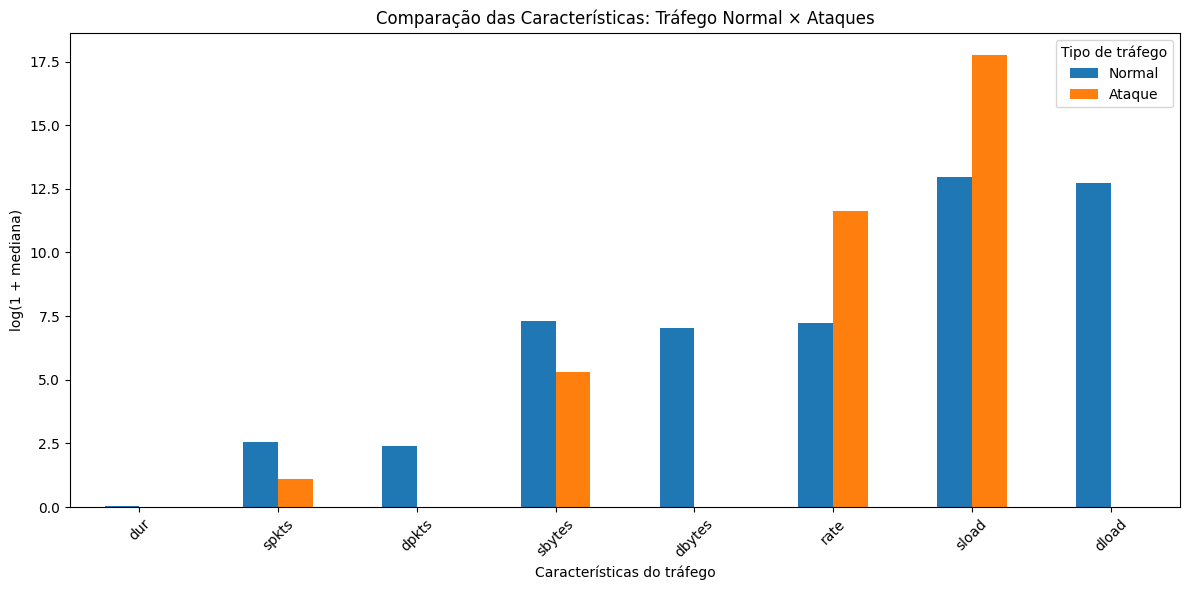

In [19]:
# Medianas de cada grupo
medianas = df.groupby('label')[variaveis_numericas].median()

# Transformação logarítmica apenas para visualização
medianas_log = np.log1p(medianas)

# Transpõe para facilitar o gráfico
medianas_log = medianas_log.T

medianas_log.columns = ['Normal', 'Ataque']

# Gráfico
medianas_log.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Comparação das Características: Tráfego Normal × Ataques')
plt.xlabel('Características do tráfego')
plt.ylabel('log(1 + mediana)')
plt.xticks(rotation=45)

plt.legend(title='Tipo de tráfego')

plt.tight_layout()
plt.show()

### Interpretação

A comparação visual reforça as diferenças observadas entre o tráfego normal
e os registros associados a ataques.

O tráfego normal apresenta valores medianos superiores em características como
`spkts`, `dpkts`, `sbytes`, `dbytes` e `dload`. Em especial, `dpkts`, `dbytes`
e `dload` apresentam mediana igual a zero nos registros de ataque, enquanto
possuem valores mais elevados no tráfego normal.

Por outro lado, os registros associados a ataques apresentam valores
consideravelmente superiores para `rate` e `sload`, indicando diferenças
importantes no comportamento da taxa e da carga de transmissão.

Esses resultados demonstram que existem padrões distintos entre os tipos de
tráfego. Entretanto, essas diferenças não garantem que os algoritmos de
agrupamento separarão perfeitamente tráfego normal e ataques, pois a formação
dos clusters dependerá da combinação de todas as características utilizadas.

## 10. Principais Padrões Identificados

A análise exploratória permitiu identificar diversos padrões relevantes no
conjunto de dados UNSW-NB15:

- Existe predominância de registros associados a ataques em relação ao tráfego normal.

- Apesar da existência de 133 protocolos diferentes, grande parte dos registros
está concentrada nos protocolos TCP e UDP.

- Na variável `service`, uma parcela significativa das conexões não possui um
serviço específico identificado. Entre os serviços identificados, DNS e HTTP
apresentam maior frequência.

- Os estados INT e FIN concentram a maior parte dos registros da variável
`state`, enquanto alguns estados possuem ocorrência muito baixa.

- As variáveis numéricas apresentam distribuições assimétricas, diferenças
significativas de escala e presença de valores extremos.

- Foram identificadas fortes correlações entre `spkts` e `sbytes` (0,96) e
entre `dpkts` e `dbytes` (0,97), indicando possível redundância de informação
entre algumas características.

- A comparação entre tráfego normal e ataques mostrou diferenças importantes
em diversas variáveis. Os ataques apresentam valores medianos superiores para
`rate` e `sload`, enquanto o tráfego normal apresenta valores maiores em
diversas características relacionadas à quantidade de pacotes e bytes.

Esses padrões indicam que o conjunto de dados possui características capazes
de representar diferentes comportamentos de tráfego, justificando a aplicação
de técnicas de segmentação e agrupamento nas próximas etapas.

## 11. Conclusões da Análise Exploratória

A análise exploratória demonstrou que o dataset UNSW-NB15 apresenta quantidade
suficiente de registros e diversidade de características para o desenvolvimento
do projeto de segmentação e agrupamento de tráfego de rede.

Foram observadas diferenças de distribuição, escala, frequência e correlação
entre as variáveis, além da presença de valores extremos e categorias com baixa
representatividade. Também foram identificadas diferenças relevantes entre os
perfis de tráfego normal e de ataques.

Os resultados da EDA indicam a necessidade de realizar uma etapa de preparação
dos dados antes da aplicação dos algoritmos de clustering. Entre os principais
pontos a serem considerados estão o tratamento das variáveis categóricas,
a transformação de distribuições muito assimétricas, o escalonamento das
variáveis numéricas e a avaliação dos valores extremos.

As variáveis `label` e `attack_cat` não serão utilizadas como entrada dos
algoritmos de agrupamento. Elas serão preservadas para permitir, posteriormente,
a análise e avaliação da composição dos clusters encontrados.

## TRATAMENTO DE DADOS

Após a análise exploratória, é necessário preparar os dados para a aplicação
dos algoritmos de agrupamento.

Nesta etapa serão tratados valores ausentes, registros duplicados, valores
extremos e variáveis categóricas. Também será realizado o escalonamento das
características numéricas.

O objetivo é produzir um conjunto de dados adequado para algoritmos de
clustering baseados em medidas de distância, preservando as informações
relevantes do tráfego de rede.

In [20]:
# Cria uma cópia para o tratamento
df_tratado = df.copy()

print("Dataset original:", df.shape)
print("Dataset para tratamento:", df_tratado.shape)

Dataset original: (175341, 36)
Dataset para tratamento: (175341, 36)


### Justificativa

Foi criada uma cópia do conjunto de dados original para que as transformações
realizadas durante o tratamento não alterem os dados utilizados na análise
exploratória.

In [21]:
total_ausentes = df_tratado.isnull().sum().sum()

print("Total de valores ausentes:", total_ausentes)

Total de valores ausentes: 0


### Tratamento de valores ausentes

Não foram identificados valores ausentes no conjunto de dados. Dessa forma,
não foi necessário realizar remoção de registros ou técnicas de imputação.

A ausência de valores nulos permite preservar todos os registros nesta etapa
do tratamento.

In [22]:
duplicados = df_tratado.duplicated().sum()

print("Registros identificados como duplicados:", duplicados)
print("Registros mantidos:", len(df_tratado))

Registros identificados como duplicados: 78519
Registros mantidos: 175341


### Tratamento de registros duplicados

Foram identificados registros com características duplicadas no conjunto de
dados. Entretanto, esses registros não foram removidos automaticamente.

Como o dataset representa eventos de tráfego de rede, registros com as mesmas
características podem corresponder a diferentes ocorrências de comunicação.
A remoção indiscriminada poderia eliminar padrões repetitivos relevantes para
a identificação dos agrupamentos.

Por esse motivo, os registros serão inicialmente preservados.

In [23]:
colunas_excluir = ['label', 'attack_cat', 'id']

colunas_excluir = [
    coluna for coluna in colunas_excluir
    if coluna in df_tratado.columns
]

X = df_tratado.drop(columns=colunas_excluir)

print("Colunas removidas do clustering:")
print(colunas_excluir)

print("\nQuantidade de variáveis utilizadas:")
print(X.shape[1])

Colunas removidas do clustering:
['label', 'attack_cat']

Quantidade de variáveis utilizadas:
34


### Separação dos rótulos

As variáveis `label` e `attack_cat` não serão utilizadas como entrada dos
algoritmos de agrupamento, pois representam informações conhecidas sobre a
classificação dos registros.

A utilização dessas variáveis durante o treinamento introduziria informações
sobre a resposta esperada e prejudicaria a natureza não supervisionada do
projeto.

Essas informações serão preservadas separadamente e utilizadas posteriormente
para avaliar e interpretar a composição dos clusters encontrados.

In [24]:
variaveis_log = [
    'dur',
    'spkts',
    'dpkts',
    'sbytes',
    'dbytes',
    'rate',
    'sload',
    'dload'
]

# Mantém apenas variáveis existentes
variaveis_log = [
    coluna for coluna in variaveis_log
    if coluna in X.columns
]

for coluna in variaveis_log:
    X[coluna] = np.log1p(X[coluna])

print("Transformação logarítmica aplicada em:")
print(variaveis_log)

Transformação logarítmica aplicada em:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload']


### Tratamento de valores extremos e assimetria

A análise exploratória identificou distribuições fortemente assimétricas e
uma quantidade relevante de valores extremos em diversas características
numéricas.

Esses registros não foram removidos automaticamente, pois valores extremos
podem representar comportamentos reais e potencialmente relevantes no contexto
de segurança de redes.

Para reduzir a influência de valores muito elevados e diminuir a assimetria,
foi aplicada a transformação `log(1+x)` em algumas das principais variáveis
numéricas analisadas.

Essa transformação reduz a diferença entre valores muito pequenos e muito
elevados sem eliminar os registros originais.

In [25]:
if 'service' in X.columns:
    X['service'] = X['service'].astype('object')
    X['service'] = X['service'].replace('-', 'unknown')

print("Valor '-' de service convertido para 'unknown'.")

Valor '-' de service convertido para 'unknown'.


In [26]:
variaveis_categoricas = [
    coluna for coluna in ['proto', 'service', 'state']
    if coluna in X.columns
]

print("Variáveis categóricas:")
print(variaveis_categoricas)

X_encoded = pd.get_dummies(
    X,
    columns=variaveis_categoricas,
    dtype=int
)

print("\nAntes da codificação:", X.shape)
print("Depois da codificação:", X_encoded.shape)

Variáveis categóricas:
['proto', 'service', 'state']

Antes da codificação: (175341, 34)
Depois da codificação: (175341, 186)


### Codificação das variáveis categóricas

As variáveis `proto`, `service` e `state` possuem informações categóricas e,
portanto, não podem ser utilizadas diretamente por algoritmos como o K-Means.

O valor "-" encontrado na variável `service` foi representado como `unknown`,
indicando que não existe um serviço específico identificado naquele registro.

Em seguida, foi utilizada a técnica One-Hot Encoding, que cria variáveis
binárias para representar cada categoria sem estabelecer uma relação de ordem
artificial entre protocolos, serviços ou estados de conexão.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

print("Dimensões finais:")
print(X_scaled.shape)

Dimensões finais:
(175341, 186)


In [28]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_encoded.columns,
    index=X_encoded.index
)

display(X_scaled.head())

,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,...,service_unknown,state_CON,state_ECO,state_FIN,state_INT,state_PAR,state_REQ,state_RST,state_URN,state_no
0,-0.342123,-0.068307,0.140261,-0.441590,0.334160,-0.852011,-0.937019,0.591119,-0.075040,-0.131759,...,0.928441,-0.284764,-0.008273,1.119382,-0.940239,-0.002388,-0.10717,-0.021762,-0.002388,-0.002388
1,0.247757,0.597577,1.463624,0.188354,1.720441,-0.838341,-1.049058,1.295137,-0.044739,0.190621,...,0.928441,-0.284764,-0.008273,1.119382,-0.940239,-0.002388,-0.10717,-0.021762,-0.002388,-0.002388
2,0.956178,0.151267,0.928674,-0.234394,1.427966,-1.237125,-1.408041,0.930891,-0.059890,-0.017978,...,0.928441,-0.284764,-0.008273,1.119382,-0.940239,-0.002388,-0.10717,-0.021762,-0.002388,-0.002388
3,0.989886,0.472549,0.755846,0.094296,0.711339,-1.245081,-1.289018,0.431105,-0.059890,-0.074868,...,-1.077075,-0.284764,-0.008273,1.119382,-0.940239,-0.002388,-0.10717,-0.021762,-0.002388,-0.002388
4,0.049848,0.326594,0.357032,-0.003462,0.445572,-1.040160,-1.044852,0.460678,-0.044739,-0.112795,...,0.928441,-0.284764,-0.008273,1.119382,-0.940239,-0.002388,-0.10717,-0.021762,-0.002388,-0.002388


### Escalonamento das variáveis

Após a codificação, foi aplicado o `StandardScaler` para padronizar as
características utilizadas pelos algoritmos de agrupamento.

O escalonamento é necessário porque as variáveis originais apresentam escalas
muito diferentes. Sem essa etapa, características com valores numericamente
maiores poderiam exercer influência excessiva no cálculo das distâncias.

A padronização permite que as diferentes características contribuam de maneira
mais equilibrada para a formação dos clusters.

In [29]:
print("===== RESULTADO DO TRATAMENTO =====")

print("\nDataset original:")
print(df.shape)

print("\nDados utilizados antes da codificação:")
print(X.shape)

print("\nDados após One-Hot Encoding:")
print(X_encoded.shape)

print("\nDados finais escalonados:")
print(X_scaled.shape)

print("\nValores ausentes nos dados finais:")
print(X_scaled.isnull().sum().sum())

print("\nValores infinitos:")
print(np.isinf(X_scaled.to_numpy()).sum())

===== RESULTADO DO TRATAMENTO =====

Dataset original:
(175341, 36)

Dados utilizados antes da codificação:
(175341, 34)

Dados após One-Hot Encoding:
(175341, 186)

Dados finais escalonados:
(175341, 186)

Valores ausentes nos dados finais:
0

Valores infinitos:
0


## Conclusão do Tratamento dos Dados

Após o tratamento, o conjunto de dados encontra-se preparado para a etapa de
modelagem.

Não foi necessária imputação de valores ausentes. Os registros duplicados e
valores extremos foram preservados devido à natureza dos dados de tráfego de
rede, enquanto transformações logarítmicas foram utilizadas para reduzir a
assimetria de algumas variáveis.

As variáveis categóricas foram transformadas por meio de One-Hot Encoding e
as características foram posteriormente padronizadas. Além disso, `label` e
`attack_cat` foram excluídas das características utilizadas no agrupamento,
sendo preservadas apenas para avaliação posterior.

O conjunto resultante poderá ser utilizado na aplicação e comparação dos
algoritmos de clustering.

#  Construção do Baseline

Nesta etapa será desenvolvido um modelo inicial de agrupamento utilizando o algoritmo K-Means, com o objetivo de estabelecer uma referência para comparação com os modelos posteriores.

O modelo utilizará inicialmente dois clusters, sem realizar otimização de hiperparâmetros. Essa configuração permitirá observar como os registros de tráfego de rede são agrupados com base em suas características.

As variáveis `label` e `attack_cat` não serão utilizadas na formação dos clusters, preservando a natureza não supervisionada do projeto.

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# Dados preparados na etapa 4
X_baseline = X_scaled

# Criação do modelo baseline
modelo_baseline = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Treinamento e formação dos clusters
clusters_baseline = modelo_baseline.fit_predict(X_baseline)

print("Baseline executado com sucesso!")
print("Quantidade de clusters:", len(np.unique(clusters_baseline)))


Baseline executado com sucesso!
Quantidade de clusters: 2


In [31]:
from sklearn.metrics import silhouette_score
import pandas as pd

# Quantidade de registros em cada cluster
contagem_clusters = pd.Series(
    clusters_baseline
).value_counts().sort_index()

print("===== RESULTADOS DO BASELINE =====")

print("\nDistribuição dos clusters:")
display(contagem_clusters)

# Inércia do modelo
print("\nInércia:", modelo_baseline.inertia_)

# Silhouette Score utilizando uma amostra
silhouette = silhouette_score(
    X_baseline,
    clusters_baseline,
    sample_size=3000,
    random_state=42
)

print("\nSilhouette Score:", round(silhouette, 4))

===== RESULTADOS DO BASELINE =====

Distribuição dos clusters:


,count
0,79221
1,96120



Inércia: 30267908.30330514

Silhouette Score: 0.2223


### Interpretação dos Resultados do Baseline

O modelo baseline foi desenvolvido utilizando o algoritmo K-Means com dois clusters, sem otimização de hiperparâmetros, a partir dos dados previamente tratados e padronizados.

O algoritmo distribuiu os 175.341 registros em dois grupos: o Cluster 0, com 79.221 registros (aproximadamente 45,2%), e o Cluster 1, com 96.120 registros (aproximadamente 54,8%). Essa distribuição demonstra que os agrupamentos apresentam tamanhos relativamente próximos.

A inércia obtida foi de 30.267.908,30, valor que será utilizado como referência para comparar outras configurações do K-Means.

O Silhouette Score, calculado utilizando uma amostra de 3.000 registros, foi de 0,2223. Esse resultado sugere que os grupos possuem separação relativamente baixa, indicando a possibilidade de sobreposição ou de uma estrutura de agrupamento mais complexa.

Embora o modelo tenha conseguido organizar os registros em dois grupos, ainda não é possível afirmar que esses agrupamentos correspondam diretamente ao tráfego normal e aos ataques cibernéticos.

Dessa forma, o baseline será utilizado como referência inicial para avaliar se diferentes algoritmos e configurações conseguem produzir agrupamentos mais consistentes e interpretáveis.

### Conclusão do Baseline

A construção do baseline permitiu estabelecer os primeiros resultados quantitativos do projeto de segmentação de tráfego de rede.

O K-Means com dois clusters apresentou uma distribuição relativamente equilibrada entre os grupos, porém obteve um Silhouette Score de 0,2223, sugerindo limitações na separação dos registros.

Esses resultados justificam a realização de novos experimentos com diferentes algoritmos e configurações, buscando identificar agrupamentos que representem melhor a diversidade dos comportamentos presentes no dataset UNSW-NB15.

# 6. Implementação e Comparação dos Algoritmos

Nesta etapa serão implementados e comparados diferentes algoritmos de agrupamento, visando investigar a capacidade de identificar padrões semelhantes entre registros de tráfego de rede.

Serão considerados os algoritmos K-Means, MiniBatch K-Means e DBSCAN, que utilizam diferentes estratégias para identificar agrupamentos.

Inicialmente, será analisado o comportamento do K-Means com diferentes quantidades de clusters. Posteriormente, os demais algoritmos serão implementados para comparação.

As variáveis `label` e `attack_cat` permanecerão excluídas das características utilizadas na formação dos agrupamentos.

In [32]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# Amostra de 20 mil registros para os experimentos
X_amostra = X_scaled.sample(
    n=20000,
    random_state=42
)

# Valores de K que serão testados
valores_k = [2, 3, 4, 5, 6]

resultados_kmeans = []

for k in valores_k:

    print(f"Executando K-Means com k={k}...")

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = modelo.fit_predict(X_amostra)

    # Avaliação em uma amostra para reduzir o custo
    silhouette = silhouette_score(
        X_amostra,
        clusters,
        sample_size=2000,
        random_state=42
    )

    resultados_kmeans.append({
        'K': k,
        'Inércia': modelo.inertia_,
        'Silhouette Score': silhouette
    })

resultados_kmeans_df = pd.DataFrame(resultados_kmeans)

print("\nResultados:")
display(resultados_kmeans_df)


Executando K-Means com k=2...
Executando K-Means com k=3...
Executando K-Means com k=4...
Executando K-Means com k=5...
Executando K-Means com k=6...

Resultados:


,K,Inércia,Silhouette Score
0,2,3.278020e+06,0.233927
1,3,3.225520e+06,0.239410
2,4,3.186908e+06,0.215564
3,5,3.141592e+06,0.258202
4,6,3.097257e+06,0.257830


### Avaliação de Diferentes Quantidades de Clusters

Para investigar a influência do número de agrupamentos, foram realizados experimentos com o algoritmo K-Means utilizando valores de K entre 2 e 6.

Nesta análise inicial, foi selecionada uma amostra aleatória de 20.000 registros, visando reduzir o custo computacional e permitir a comparação de diferentes configurações.

Foram utilizadas a inércia e a métrica Silhouette Score para avaliar a estrutura dos agrupamentos, considerando a compactação dos registros em seus grupos e a separação entre clusters.

Os resultados serão analisados para identificar configurações promissoras, que poderão ser avaliadas posteriormente com maior profundidade.

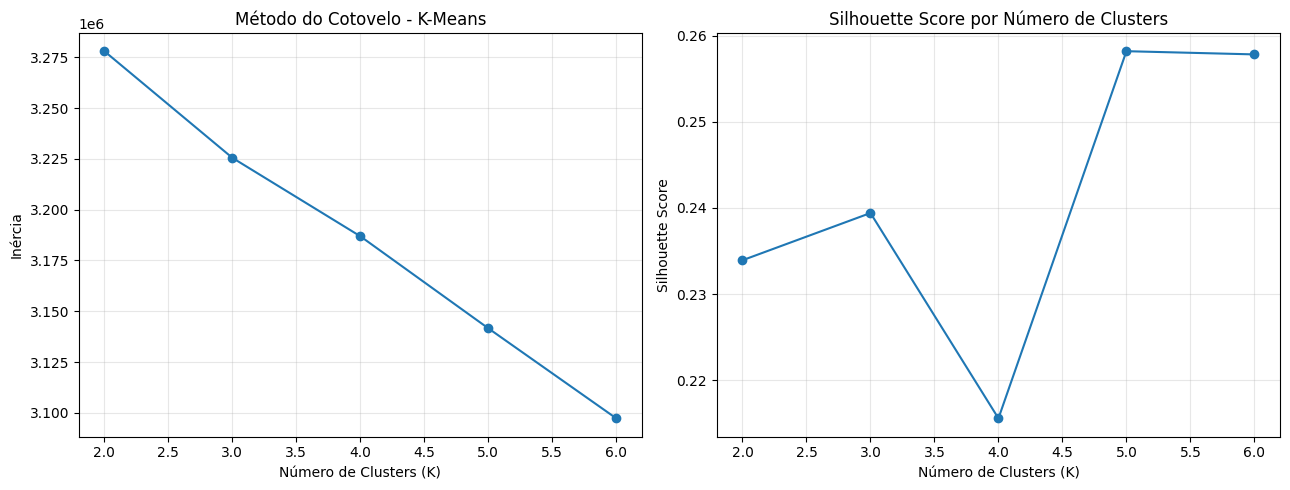

In [33]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico da inércia
axes[0].plot(
    resultados_kmeans_df['K'],
    resultados_kmeans_df['Inércia'],
    marker='o'
)

axes[0].set_title('Método do Cotovelo - K-Means')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].grid(alpha=0.3)

# Gráfico Silhouette
axes[1].plot(
    resultados_kmeans_df['K'],
    resultados_kmeans_df['Silhouette Score'],
    marker='o'
)

axes[1].set_title('Silhouette Score por Número de Clusters')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Interpretação dos Resultados — K-Means

Foram realizados experimentos com o algoritmo K-Means utilizando diferentes quantidades de clusters, variando de 2 a 6, com uma amostra de 20.000 registros do dataset UNSW-NB15.

A análise da inércia demonstrou uma redução progressiva conforme o número de clusters aumentou. Entretanto, o método do cotovelo não apresentou um ponto de inflexão claramente definido, dificultando a identificação de uma quantidade ideal de agrupamentos apenas por essa métrica.

Em relação ao Silhouette Score, o melhor resultado foi obtido com cinco clusters (K=5), alcançando aproximadamente 0,2582. O modelo com seis clusters apresentou desempenho semelhante, com 0,2578.

Esses resultados indicam que a utilização de cinco clusters é uma configuração promissora para representar diferentes perfis de tráfego de rede. Entretanto, os valores de Silhouette ainda sugerem uma separação relativamente limitada entre os grupos.

Dessa forma, K=5 será considerado um candidato para análises posteriores, sendo necessário investigar sua estabilidade, a distribuição dos registros e a interpretação dos agrupamentos antes de definir a configuração final.

### 6.5 Implementação do MiniBatch K-Means

O MiniBatch K-Means é uma variação do algoritmo K-Means tradicional que utiliza pequenos subconjuntos de dados durante o processo de atualização dos centros dos agrupamentos.

Essa abordagem busca reduzir o custo computacional, sendo especialmente útil em conjuntos de dados com grande quantidade de registros.

Neste experimento, serão utilizados os mesmos 20.000 registros e os mesmos valores de K considerados anteriormente, permitindo comparar o desempenho dos dois algoritmos em condições semelhantes.

In [34]:

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import pandas as pd

resultados_minibatch = []

for k in [2, 3, 4, 5, 6]:

    print(f"Executando MiniBatch K-Means com k={k}...")

    modelo_mb = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=1024,
        n_init=10,
        max_iter=100
    )

    clusters_mb = modelo_mb.fit_predict(X_amostra)

    silhouette_mb = silhouette_score(
        X_amostra,
        clusters_mb,
        sample_size=2000,
        random_state=42
    )

    resultados_minibatch.append({
        'K': k,
        'Inércia': modelo_mb.inertia_,
        'Silhouette Score': silhouette_mb
    })

resultados_minibatch_df = pd.DataFrame(
    resultados_minibatch
)

print("\nResultados MiniBatch K-Means:")
display(resultados_minibatch_df)


Executando MiniBatch K-Means com k=2...
Executando MiniBatch K-Means com k=3...
Executando MiniBatch K-Means com k=4...
Executando MiniBatch K-Means com k=5...
Executando MiniBatch K-Means com k=6...

Resultados MiniBatch K-Means:


,K,Inércia,Silhouette Score
0,2,3.278329e+06,0.233927
1,3,3.230514e+06,0.217882
2,4,3.221607e+06,0.060804
3,5,3.167605e+06,0.160009
4,6,3.101081e+06,0.117263


### Comparação entre K-Means e MiniBatch K-Means

A comparação entre os algoritmos K-Means e MiniBatch K-Means foi realizada utilizando uma amostra de 20.000 registros do dataset UNSW-NB15, considerando quantidades de clusters entre 2 e 6.

O K-Means tradicional apresentou os maiores valores de Silhouette Score na maioria das configurações avaliadas. Seu melhor resultado foi obtido com cinco clusters, alcançando 0,2582.

Por sua vez, o MiniBatch K-Means apresentou seu melhor resultado com dois clusters, alcançando aproximadamente 0,2339. Para configurações com quatro, cinco e seis clusters, foram observados resultados inferiores aos obtidos pelo K-Means tradicional.

Esses resultados sugerem que, nas condições experimentais adotadas, o K-Means tradicional conseguiu produzir agrupamentos com melhor separação e coesão segundo a métrica Silhouette.

Entretanto, a comparação ainda não considera o tempo de execução e a estabilidade dos modelos. Esses aspectos poderão ser investigados posteriormente para avaliar o equilíbrio entre qualidade dos agrupamentos e eficiência computacional.

### 6.8 Implementação do DBSCAN

O DBSCAN é um algoritmo de agrupamento baseado em densidade, capaz de identificar regiões com concentração elevada de observações e classificar registros isolados como ruído.

Diferentemente do K-Means, o DBSCAN não exige a definição prévia do número de clusters. A formação dos grupos depende principalmente dos parâmetros `eps` e `min_samples`.

Devido à dimensionalidade e ao volume do dataset, será utilizada inicialmente uma amostra de 5.000 registros, juntamente com redução de dimensionalidade por PCA, visando tornar o experimento computacionalmente viável.

Os resultados serão analisados de forma exploratória, sem considerar automaticamente os pontos classificados como ruído como atividades maliciosas.

In [37]:

from sklearn.decomposition import PCA
import numpy as np

# Amostra de 5.000 registros
X_dbscan = X_amostra.sample(
    n=5000,
    random_state=42
)

# Redução de dimensionalidade
pca = PCA(
    n_components=0.90,
    svd_solver='full'
)

X_dbscan_pca = pca.fit_transform(X_dbscan)

print("Dimensões antes do PCA:", X_dbscan.shape)
print("Dimensões depois do PCA:", X_dbscan_pca.shape)

print(
    "Variância explicada:",
    round(sum(pca.explained_variance_ratio_) * 100, 2),
    "%"
)


Dimensões antes do PCA: (5000, 186)
Dimensões depois do PCA: (5000, 112)
Variância explicada: 90.26 %


### Interpretação da Redução de Dimensionalidade

A aplicação do PCA reduziu a dimensionalidade dos dados de 186 para 112 características, preservando aproximadamente 90,26% da variância total.

Essa redução permite representar grande parte da variabilidade dos dados utilizando menos componentes, contribuindo para diminuir a complexidade computacional dos experimentos.

Entretanto, o conjunto resultante ainda apresenta dimensionalidade elevada, o que pode dificultar o desempenho de algoritmos baseados em densidade, como o DBSCAN.

Dessa forma, será necessário investigar parâmetros adequados para identificar agrupamentos significativos.

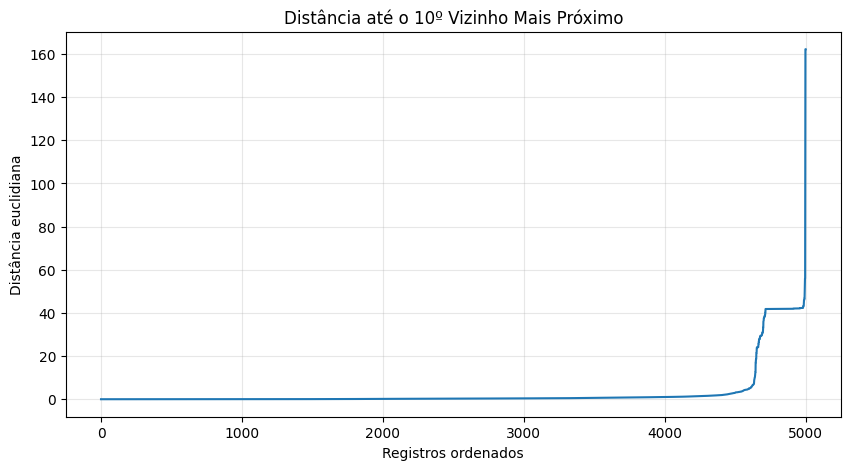

Percentis das distâncias:
50%: 0.2779386689934545
75%: 0.7800472808720618
90%: 3.0060499919745327
95%: 41.822628102851155


In [38]:

from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Número mínimo inicial de vizinhos
min_samples = 10

# Encontrando os vizinhos mais próximos
vizinhos = NearestNeighbors(
    n_neighbors=min_samples,
    n_jobs=-1
)

vizinhos.fit(X_dbscan_pca)

distancias, indices = vizinhos.kneighbors(X_dbscan_pca)

# Distância até o 10º vizinho
distancias_k = np.sort(distancias[:, -1])

# Gráfico
plt.figure(figsize=(10, 5))

plt.plot(distancias_k)

plt.title('Distância até o 10º Vizinho Mais Próximo')
plt.xlabel('Registros ordenados')
plt.ylabel('Distância euclidiana')

plt.grid(alpha=0.3)
plt.show()

print("Percentis das distâncias:")
print("50%:", np.percentile(distancias_k, 50))
print("75%:", np.percentile(distancias_k, 75))
print("90%:", np.percentile(distancias_k, 90))
print("95%:", np.percentile(distancias_k, 95))

### Interpretação das Distâncias dos Vizinhos

A análise das distâncias até o décimo vizinho mais próximo revelou uma distribuição bastante desigual entre os registros.

A maior parte das observações apresenta distâncias relativamente pequenas, com mediana de aproximadamente 0,278 e terceiro quartil de 0,780. Entretanto, a curva apresenta um crescimento acentuado em sua região final, com o percentil 95 alcançando aproximadamente 41,823.

Esse comportamento sugere a existência de regiões com diferentes densidades no espaço de características, incluindo registros relativamente isolados.

Os resultados serão utilizados como referência para testar diferentes valores do parâmetro `eps` no DBSCAN, sem assumir que pontos isolados correspondem necessariamente a ataques cibernéticos.

In [39]:

from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

# Valores iniciais de eps
valores_eps = [0.5, 1.0, 2.0, 3.0, 5.0]

resultados_dbscan = []

for eps in valores_eps:

    print(f"Executando DBSCAN com eps={eps}...")

    modelo_dbscan = DBSCAN(
        eps=eps,
        min_samples=10,
        metric='euclidean',
        n_jobs=-1
    )

    clusters = modelo_dbscan.fit_predict(X_dbscan_pca)

    # Quantidade de clusters, excluindo o ruído (-1)
    n_clusters = len(set(clusters) - {-1})

    # Quantidade de pontos classificados como ruído
    n_ruido = np.sum(clusters == -1)

    percentual_ruido = (
        n_ruido / len(clusters)
    ) * 100

    resultados_dbscan.append({
        'eps': eps,
        'Clusters': n_clusters,
        'Registros de ruído': n_ruido,
        'Ruído (%)': round(percentual_ruido, 2)
    })

resultados_dbscan_df = pd.DataFrame(
    resultados_dbscan
)

print("\nResultados do DBSCAN:")
display(resultados_dbscan_df)


Executando DBSCAN com eps=0.5...
Executando DBSCAN com eps=1.0...
Executando DBSCAN com eps=2.0...
Executando DBSCAN com eps=3.0...
Executando DBSCAN com eps=5.0...

Resultados do DBSCAN:


,eps,Clusters,Registros de ruído,Ruído (%)
0,0.5,24,1411,28.22
1,1.0,29,828,16.56
2,2.0,19,534,10.68
3,3.0,15,479,9.58
4,5.0,10,381,7.62


### Interpretação dos Resultados — DBSCAN

Foram realizados experimentos com o algoritmo DBSCAN utilizando diferentes valores do parâmetro `eps`, variando entre 0,5 e 5,0, mantendo `min_samples=10`.

Os resultados demonstraram que o parâmetro `eps` influencia significativamente a quantidade de clusters identificados e a proporção de registros classificados como ruído.

Com `eps=0,5`, foram identificados 24 clusters e 28,22% dos registros foram classificados como ruído. Já com `eps=5,0`, a quantidade de clusters diminuiu para 10, enquanto a proporção de ruído foi reduzida para 7,62%.

O maior número de agrupamentos foi encontrado com `eps=1,0`, totalizando 29 clusters.

Esses resultados demonstram a sensibilidade do DBSCAN aos parâmetros utilizados e sugerem a existência de regiões com diferentes densidades no espaço de características.

Entretanto, a quantidade de clusters e a proporção de ruído não são suficientes para determinar a melhor configuração. Será necessário avaliar também a qualidade dos agrupamentos e sua interpretação no contexto do tráfego de rede.

In [40]:

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

avaliacao_dbscan = []

for eps in [0.5, 1.0, 2.0, 3.0, 5.0]:

    print(f"Avaliando DBSCAN com eps={eps}...")

    modelo = DBSCAN(
        eps=eps,
        min_samples=10,
        n_jobs=-1
    )

    clusters = modelo.fit_predict(X_dbscan_pca)

    # Remover ruído da avaliação de Silhouette
    mascara = clusters != -1

    dados_validos = X_dbscan_pca[mascara]
    clusters_validos = clusters[mascara]

    n_clusters = len(np.unique(clusters_validos))

    if n_clusters >= 2 and len(clusters_validos) > n_clusters:

        score = silhouette_score(
            dados_validos,
            clusters_validos,
            sample_size=min(2000, len(dados_validos)),
            random_state=42
        )

    else:
        score = np.nan

    avaliacao_dbscan.append({
        'eps': eps,
        'Clusters': n_clusters,
        'Silhouette Score': score,
        'Ruído (%)': round(
            (np.sum(clusters == -1) / len(clusters)) * 100,
            2
        )
    })

avaliacao_dbscan_df = pd.DataFrame(avaliacao_dbscan)

print("\nAvaliação DBSCAN:")
display(avaliacao_dbscan_df)


Avaliando DBSCAN com eps=0.5...
Avaliando DBSCAN com eps=1.0...
Avaliando DBSCAN com eps=2.0...
Avaliando DBSCAN com eps=3.0...
Avaliando DBSCAN com eps=5.0...

Avaliação DBSCAN:


,eps,Clusters,Silhouette Score,Ruído (%)
0,0.5,24,0.639671,28.22
1,1.0,29,0.525168,16.56
2,2.0,19,0.516219,10.68
3,3.0,15,0.490095,9.58
4,5.0,10,0.299796,7.62


### Interpretação da Avaliação do DBSCAN

A avaliação do DBSCAN demonstrou diferenças significativas na qualidade dos agrupamentos conforme a variação do parâmetro `eps`.

O maior Silhouette Score foi obtido com `eps=0,5`, alcançando aproximadamente 0,6397 e identificando 24 clusters. Entretanto, essa configuração também apresentou a maior proporção de registros classificados como ruído, correspondendo a 28,22% das observações.

Com o aumento do parâmetro `eps`, observou-se uma redução progressiva da proporção de ruído. Para `eps=5,0`, essa proporção caiu para 7,62%, acompanhada de uma redução do Silhouette Score para aproximadamente 0,2998.

Esses resultados demonstram a existência de um compromisso entre a separação dos grupos identificados e a quantidade de registros que permanecem fora dos agrupamentos.

É importante destacar que o Silhouette Score foi calculado apenas sobre os registros pertencentes aos clusters, excluindo os pontos classificados como ruído. Dessa forma, os valores não representam a qualidade do agrupamento de todo o conjunto de dados.

Os resultados são promissores, mas ainda não permitem definir uma configuração final. Será necessário considerar a distribuição dos clusters, a proporção de ruído e a capacidade de interpretação dos grupos encontrados.'

In [41]:

from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# Mesmos 5.000 registros e mesma representação PCA
X_comparacao = X_dbscan_pca

modelos = {
    "K-Means": KMeans(
        n_clusters=5,
        random_state=42,
        n_init=10
    ),
    "MiniBatch K-Means": MiniBatchKMeans(
        n_clusters=2,
        random_state=42,
        batch_size=1024,
        n_init=10
    ),
    "DBSCAN": DBSCAN(
        eps=0.5,
        min_samples=10,
        n_jobs=-1
    )
}

resultados_comparacao = []

for nome, modelo in modelos.items():

    print(f"Executando {nome}...")

    clusters = modelo.fit_predict(X_comparacao)

    # Para DBSCAN, excluímos ruído do Silhouette
    mascara = clusters != -1

    dados_validos = X_comparacao[mascara]
    clusters_validos = clusters[mascara]

    n_clusters = len(np.unique(clusters_validos))

    ruido = np.mean(clusters == -1) * 100

    if n_clusters >= 2:
        score = silhouette_score(
            dados_validos,
            clusters_validos,
            sample_size=min(2000, len(dados_validos)),
            random_state=42
        )
    else:
        score = np.nan

    resultados_comparacao.append({
        "Algoritmo": nome,
        "Clusters": n_clusters,
        "Silhouette Score": round(score, 4),
        "Ruído (%)": round(ruido, 2)
    })

comparacao_final_df = pd.DataFrame(resultados_comparacao)

display(comparacao_final_df)


Executando K-Means...
Executando MiniBatch K-Means...
Executando DBSCAN...


,Algoritmo,Clusters,Silhouette Score,Ruído (%)
0,K-Means,5,0.2500,0.00
1,MiniBatch K-Means,2,0.2412,0.00
2,DBSCAN,24,0.6397,28.22


### Interpretação da Comparação dos Algoritmos

A comparação entre K-Means, MiniBatch K-Means e DBSCAN foi realizada utilizando uma amostra de 5.000 registros do dataset UNSW-NB15, após redução de dimensionalidade por PCA.

O K-Means formou cinco clusters e apresentou Silhouette Score de 0,2500, enquanto o MiniBatch K-Means identificou dois clusters, alcançando 0,2412. Ambos atribuíram todos os registros aos agrupamentos encontrados.

O DBSCAN identificou 24 clusters e apresentou Silhouette Score de 0,6397, valor superior ao observado nos demais algoritmos. Entretanto, 28,22% dos registros foram classificados como ruído e excluídos do cálculo dessa métrica.

Portanto, embora o DBSCAN tenha apresentado maior separação entre os grupos identificados segundo o Silhouette Score, não é possível considerá-lo definitivamente superior aos demais algoritmos.

Os resultados mostram que diferentes técnicas de agrupamento produzem estruturas distintas para o mesmo conjunto de dados. Dessa forma, a escolha do modelo mais adequado deverá considerar não apenas métricas quantitativas, mas também a distribuição dos clusters, a estabilidade dos resultados e sua interpretação no contexto da segurança de redes.

### Conclusão da Implementação e Comparação dos Algoritmos

A implementação dos três algoritmos permitiu investigar diferentes estratégias de agrupamento aplicadas ao tráfego de rede.

O K-Means e o MiniBatch K-Means apresentaram resultados relativamente próximos, enquanto o DBSCAN demonstrou capacidade de identificar uma quantidade maior de grupos e destacar registros considerados ruído.

Entretanto, os experimentos evidenciaram que a avaliação de algoritmos de clustering exige considerar diferentes aspectos da qualidade dos agrupamentos, uma vez que métricas isoladas não são suficientes para determinar o modelo mais adequado.

Assim, os resultados obtidos serão utilizados como referência para a próxima etapa, que envolverá validação, investigação da estabilidade dos agrupamentos e ajuste dos hiperparâmetros.

# 7. Validação e Ajuste de Hiperparâmetros

Nesta etapa será investigada a estabilidade dos algoritmos de agrupamento e a influência de diferentes configurações de hiperparâmetros sobre os resultados.

Inicialmente, será avaliada a estabilidade do K-Means com cinco clusters, configuração que apresentou o maior Silhouette Score entre os valores de K testados anteriormente.

Serão realizadas diferentes execuções do algoritmo, variando a inicialização dos centros dos clusters e analisando a consistência dos resultados.

Posteriormente, serão investigados ajustes nos hiperparâmetros dos demais algoritmos, buscando identificar configurações adequadas para a segmentação do tráfego de rede.

In [42]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# Diferentes sementes de inicialização
sementes = [10, 21, 42, 77, 100]

resultados_estabilidade = []
rotulos_execucoes = []

for semente in sementes:

    print(f"Executando K-Means com random_state={semente}...")

    modelo = KMeans(
        n_clusters=5,
        random_state=semente,
        n_init=1
    )

    clusters = modelo.fit_predict(X_amostra)
    rotulos_execucoes.append(clusters)

    silhouette = silhouette_score(
        X_amostra,
        clusters,
        sample_size=2000,
        random_state=42
    )

    resultados_estabilidade.append({
        'Semente': semente,
        'Inércia': modelo.inertia_,
        'Silhouette Score': silhouette
    })

estabilidade_df = pd.DataFrame(resultados_estabilidade)

print("\nResultados da estabilidade:")
display(estabilidade_df)

print("\nDesvio padrão do Silhouette:")
print(
    round(estabilidade_df['Silhouette Score'].std(), 4)
)


Executando K-Means com random_state=10...
Executando K-Means com random_state=21...
Executando K-Means com random_state=42...
Executando K-Means com random_state=77...
Executando K-Means com random_state=100...

Resultados da estabilidade:


,Semente,Inércia,Silhouette Score
0,10,3.200650e+06,0.236623
1,21,3.164856e+06,0.256069
2,42,3.207072e+06,0.241287
3,77,3.171455e+06,0.211138
4,100,3.194936e+06,0.240723



Desvio padrão do Silhouette:
0.0163


### Interpretação da Estabilidade do K-Means

A estabilidade do algoritmo K-Means foi investigada por meio de cinco execuções independentes, utilizando diferentes sementes de inicialização e mantendo o número de clusters fixo em cinco.

Os resultados apresentaram variações nos valores de inércia e Silhouette Score. A maior pontuação de Silhouette foi de aproximadamente 0,2561, enquanto a menor foi de 0,2111.

O desvio padrão do Silhouette Score foi de 0,0163, indicando variação na qualidade dos agrupamentos conforme a inicialização utilizada.

Esses resultados sugerem que a escolha dos centros iniciais influencia a solução encontrada pelo algoritmo.

Dessa forma, a utilização de múltiplas inicializações, por meio do parâmetro `n_init`, é recomendada para reduzir a dependência de uma única inicialização e aumentar a consistência dos experimentos.

Entretanto, a semelhança entre os valores das métricas não garante que os registros tenham sido atribuídos aos mesmos grupos. Por isso, será realizada uma avaliação complementar da concordância entre os agrupamentos.

In [43]:

from sklearn.metrics import adjusted_rand_score
import pandas as pd
import numpy as np

# Compara os agrupamentos das cinco execuções
matriz_ari = np.zeros(
    (len(sementes), len(sementes))
)

for i in range(len(sementes)):
    for j in range(len(sementes)):

        matriz_ari[i, j] = adjusted_rand_score(
            rotulos_execucoes[i],
            rotulos_execucoes[j]
        )

# Organiza os resultados em uma tabela
ari_df = pd.DataFrame(
    matriz_ari,
    index=sementes,
    columns=sementes
)

print("Matriz de concordância entre os agrupamentos:")
display(ari_df.round(4))

# Média das comparações, excluindo a diagonal
valores_ari = matriz_ari[
    np.triu_indices(len(sementes), k=1)
]

print(
    "\nARI médio entre execuções:",
    round(valores_ari.mean(), 4)
)


Matriz de concordância entre os agrupamentos:


,10,21,42,77,100
10,1.0000,0.9592,0.9793,0.5379,0.9934
21,0.9592,1.0000,0.9481,0.5432,0.9589
42,0.9793,0.9481,1.0000,0.5394,0.9790
77,0.5379,0.5432,0.5394,1.0000,0.5370
100,0.9934,0.9589,0.9790,0.5370,1.0000



ARI médio entre execuções: 0.7976


### Interpretação da Concordância entre os Agrupamentos

A estabilidade dos agrupamentos foi avaliada utilizando o Adjusted Rand Index (ARI), comparando os resultados obtidos por cinco execuções do K-Means com diferentes sementes de inicialização.

O ARI médio entre as execuções foi de 0,7976, indicando concordância relativamente elevada entre os agrupamentos, embora tenham sido observadas diferenças relevantes em algumas comparações.

As inicializações com sementes 10, 21, 42 e 100 apresentaram valores de ARI superiores a 0,94 entre si, demonstrando que produziram agrupamentos bastante semelhantes.

Entretanto, a inicialização com semente 77 apresentou concordância significativamente menor com as demais, com valores próximos de 0,54.

Esses resultados demonstram que o algoritmo apresenta certa sensibilidade à escolha dos centros iniciais, podendo convergir para diferentes soluções.

Portanto, a utilização de múltiplas inicializações (`n_init=10`) é recomendada para reduzir a dependência de uma única inicialização e favorecer a seleção de soluções com menor inércia.

### 7.5 Ajuste do Parâmetro `n_init` no K-Means

Após identificar variações entre diferentes inicializações do K-Means, será investigada a influência do parâmetro `n_init` sobre a qualidade dos agrupamentos.

Esse parâmetro determina quantas inicializações independentes serão realizadas durante o treinamento, sendo selecionada a solução que apresentar menor inércia.

Serão testados diferentes valores de `n_init`, mantendo o número de clusters fixo em cinco e utilizando a mesma amostra de dados das análises anteriores.

In [44]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

valores_n_init = [1, 5, 10, 20]

resultados_n_init = []

for n in valores_n_init:

    print(f"Executando K-Means com n_init={n}...")

    modelo = KMeans(
        n_clusters=5,
        n_init=n,
        random_state=42
    )

    clusters = modelo.fit_predict(X_amostra)

    silhouette = silhouette_score(
        X_amostra,
        clusters,
        sample_size=2000,
        random_state=42
    )

    resultados_n_init.append({
        'n_init': n,
        'Inércia': modelo.inertia_,
        'Silhouette Score': silhouette
    })

resultados_n_init_df = pd.DataFrame(resultados_n_init)

print("\nResultados do ajuste de n_init:")
display(resultados_n_init_df)


Executando K-Means com n_init=1...
Executando K-Means com n_init=5...
Executando K-Means com n_init=10...
Executando K-Means com n_init=20...

Resultados do ajuste de n_init:


,n_init,Inércia,Silhouette Score
0,1,3.207072e+06,0.241287
1,5,3.193094e+06,0.059308
2,10,3.141592e+06,0.258202
3,20,3.141592e+06,0.258202


### Interpretação do Ajuste do Parâmetro `n_init`

Foram realizados experimentos com o algoritmo K-Means utilizando diferentes valores para o parâmetro `n_init`, mantendo o número de clusters fixo em cinco.

Os resultados demonstraram que o aumento no número de inicializações contribuiu para a redução da inércia. Entretanto, essa redução não foi acompanhada por melhorias consistentes no Silhouette Score.

A configuração com `n_init=5` apresentou Silhouette Score de 0,0593, inferior ao resultado obtido com apenas uma inicialização, que foi de 0,2413.

Os melhores resultados foram observados com `n_init=10` e `n_init=20`, ambos alcançando inércia de aproximadamente 3.141.592 e Silhouette Score de 0,2582.

Como o aumento de 10 para 20 inicializações não produziu melhorias observáveis nas métricas avaliadas, a configuração `n_init=10` foi selecionada como candidata para os próximos experimentos.

Essa escolha busca equilibrar a qualidade dos agrupamentos e o custo computacional, embora a estabilidade em outras amostras ainda precise ser investigada.

### 7.6 Ajuste de Hiperparâmetros do MiniBatch K-Means

Nesta etapa será investigada a influência do parâmetro `batch_size` sobre os resultados do MiniBatch K-Means.

Esse parâmetro determina a quantidade de registros processados em cada lote durante a atualização dos centros dos agrupamentos.

Serão testados diferentes tamanhos de lote, mantendo o número de clusters fixo em dois e utilizando a mesma amostra de 20.000 registros adotada nos experimentos anteriores.

O objetivo é verificar se alterações no tamanho dos lotes podem melhorar a qualidade dos agrupamentos produzidos pelo algoritmo.

In [45]:

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import pandas as pd

valores_batch = [256, 512, 1024]

resultados_batch = []

for batch in valores_batch:

    print(f"Executando MiniBatch com batch_size={batch}...")

    modelo = MiniBatchKMeans(
        n_clusters=2,
        batch_size=batch,
        n_init=10,
        random_state=42,
        max_iter=100
    )

    clusters = modelo.fit_predict(X_amostra)

    silhouette = silhouette_score(
        X_amostra,
        clusters,
        sample_size=2000,
        random_state=42
    )

    resultados_batch.append({
        'batch_size': batch,
        'Inércia': modelo.inertia_,
        'Silhouette Score': silhouette
    })

resultados_batch_df = pd.DataFrame(resultados_batch)

print("\nResultados do ajuste de batch_size:")
display(resultados_batch_df)


Executando MiniBatch com batch_size=256...
Executando MiniBatch com batch_size=512...
Executando MiniBatch com batch_size=1024...

Resultados do ajuste de batch_size:


,batch_size,Inércia,Silhouette Score
0,256,3.279419e+06,0.233927
1,512,3.278709e+06,0.234549
2,1024,3.278329e+06,0.233927


### Interpretação do Ajuste de `batch_size`

Foram realizados experimentos com o algoritmo MiniBatch K-Means utilizando diferentes tamanhos de lote (`batch_size`), mantendo dois clusters e os demais parâmetros constantes.

Os resultados apresentaram valores de Silhouette Score muito próximos entre as configurações avaliadas. O maior valor foi obtido com `batch_size=512`, alcançando aproximadamente 0,2345.

A configuração com `batch_size=1024` apresentou a menor inércia, porém não obteve o maior Silhouette Score, demonstrando que as duas métricas avaliam aspectos diferentes dos agrupamentos.

De maneira geral, os resultados sugerem que as alterações no tamanho dos lotes tiveram influência limitada sobre a qualidade dos agrupamentos neste experimento.

Assim, `batch_size=512` será considerado uma configuração candidata para o MiniBatch K-Means, embora a diferença observada não seja suficiente para demonstrar superioridade consistente sobre as demais configurações.

### 7.7 Ajuste de Hiperparâmetros do DBSCAN

Nesta etapa será investigada a influência dos parâmetros `eps` e `min_samples` sobre a formação dos agrupamentos pelo algoritmo DBSCAN.

O parâmetro `eps` determina o raio máximo de vizinhança considerado pelo algoritmo, enquanto `min_samples` estabelece a quantidade mínima de observações necessária para caracterizar uma região suficientemente densa.

Serão avaliadas diferentes combinações desses parâmetros, considerando a quantidade de clusters encontrados, o Silhouette Score e a proporção de registros classificados como ruído.

O objetivo é identificar configurações que apresentem um equilíbrio entre a separação dos grupos e a quantidade de registros não agrupados.

In [46]:

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

valores_eps = [0.5, 1.0, 2.0, 3.0]
valores_min_samples = [5, 10, 20]

resultados_ajuste_dbscan = []

for eps in valores_eps:
    for min_samples in valores_min_samples:

        print(
            f"DBSCAN: eps={eps}, "
            f"min_samples={min_samples}"
        )

        modelo = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=-1
        )

        clusters = modelo.fit_predict(X_dbscan_pca)

        # Identificando registros agrupados
        mascara = clusters != -1

        dados_validos = X_dbscan_pca[mascara]
        clusters_validos = clusters[mascara]

        n_clusters = len(np.unique(clusters_validos))

        percentual_ruido = (
            np.mean(clusters == -1) * 100
        )

        # Calcula Silhouette somente com clusters válidos
        if n_clusters >= 2 and len(clusters_validos) > n_clusters:

            silhouette = silhouette_score(
                dados_validos,
                clusters_validos,
                sample_size=min(2000, len(dados_validos)),
                random_state=42
            )

        else:
            silhouette = np.nan

        resultados_ajuste_dbscan.append({
            'eps': eps,
            'min_samples': min_samples,
            'Clusters': n_clusters,
            'Silhouette Score': silhouette,
            'Ruído (%)': round(percentual_ruido, 2)
        })

ajuste_dbscan_df = pd.DataFrame(
    resultados_ajuste_dbscan
)

print("\nResultados do ajuste do DBSCAN:")
display(ajuste_dbscan_df.round(4))


DBSCAN: eps=0.5, min_samples=5
DBSCAN: eps=0.5, min_samples=10
DBSCAN: eps=0.5, min_samples=20
DBSCAN: eps=1.0, min_samples=5
DBSCAN: eps=1.0, min_samples=10
DBSCAN: eps=1.0, min_samples=20
DBSCAN: eps=2.0, min_samples=5
DBSCAN: eps=2.0, min_samples=10
DBSCAN: eps=2.0, min_samples=20
DBSCAN: eps=3.0, min_samples=5
DBSCAN: eps=3.0, min_samples=10
DBSCAN: eps=3.0, min_samples=20

Resultados do ajuste do DBSCAN:


,eps,min_samples,Clusters,Silhouette Score,Ruído (%)
0,0.5,5,57,0.6115,21.42
1,0.5,10,24,0.6397,28.22
2,0.5,20,14,0.7517,33.82
3,1.0,5,57,0.5160,10.62
4,1.0,10,29,0.5252,16.56
5,1.0,20,16,0.6395,23.50
6,2.0,5,43,0.5347,7.28
7,2.0,10,19,0.5162,10.68
8,2.0,20,16,0.5561,12.82
9,3.0,5,37,0.4927,6.28


### Interpretação do Ajuste de Hiperparâmetros do DBSCAN

Foram avaliadas 12 combinações dos parâmetros `eps` e `min_samples`, buscando investigar sua influência sobre a formação dos agrupamentos.

Os resultados demonstraram que a escolha desses parâmetros afeta significativamente a quantidade de clusters, a proporção de registros classificados como ruído e a qualidade dos agrupamentos.

O maior Silhouette Score foi obtido com `eps=0,5` e `min_samples=20`, alcançando 0,7517 e identificando 14 clusters. Entretanto, essa configuração classificou 33,82% dos registros como ruído.

Por outro lado, a configuração `eps=3,0` e `min_samples=20` apresentou Silhouette Score de 0,5794, identificando 12 clusters e classificando 10,44% dos registros como ruído.

Os resultados evidenciam um compromisso entre a separação dos agrupamentos e a proporção de observações não agrupadas.

Como o Silhouette Score foi calculado apenas sobre os registros pertencentes aos clusters, valores elevados não representam necessariamente melhor desempenho sobre o conjunto completo.

Dessa forma, as configurações com `eps=0,5`, `min_samples=20` e `eps=3,0`, `min_samples=20` serão consideradas candidatas para análises complementares, levando em consideração a distribuição dos clusters, a estabilidade e a relevância dos agrupamentos identificados.

In [47]:

from sklearn.cluster import DBSCAN
import pandas as pd

# Configurações candidatas
configuracoes = [
    (0.5, 20),
    (3.0, 20)
]

for eps, min_samples in configuracoes:

    print(
        f"\n===== DBSCAN: eps={eps}, "
        f"min_samples={min_samples} ====="
    )

    modelo = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        n_jobs=-1
    )

    clusters = modelo.fit_predict(X_dbscan_pca)

    distribuicao = pd.Series(
        clusters
    ).value_counts().sort_index()

    print("\nDistribuição dos registros:")
    display(distribuicao.to_frame("Registros"))

    tamanhos = distribuicao.drop(
        index=-1,
        errors='ignore'
    )

    print("Quantidade de clusters:", len(tamanhos))

    if len(tamanhos) > 0:
        print("Menor cluster:", tamanhos.min())
        print("Maior cluster:", tamanhos.max())

    print(
        "Registros classificados como ruído:",
        (clusters == -1).sum()
    )



===== DBSCAN: eps=0.5, min_samples=20 =====

Distribuição dos registros:


,Registros
-1,1691
0,357
1,1126
2,466
3,249
4,210
5,87
6,211
7,82
8,153


Quantidade de clusters: 14
Menor cluster: 20
Maior cluster: 1126
Registros classificados como ruído: 1691

===== DBSCAN: eps=3.0, min_samples=20 =====

Distribuição dos registros:


,Registros
-1,522
0,358
1,46
2,1485
3,1919
4,32
5,310
6,70
7,25
8,62


Quantidade de clusters: 12
Menor cluster: 25
Maior cluster: 1919
Registros classificados como ruído: 522


### Interpretação da Distribuição dos Clusters do DBSCAN

A análise da distribuição dos clusters permitiu comparar duas configurações candidatas do algoritmo DBSCAN.

A configuração com `eps=0,5` e `min_samples=20` identificou 14 clusters, com tamanhos variando entre 20 e 1.126 registros. Entretanto, 1.691 observações foram classificadas como ruído, correspondendo a 33,82% da amostra.

Já a configuração com `eps=3,0` e `min_samples=20` identificou 12 clusters, com tamanhos entre 25 e 1.919 registros. Nessa configuração, 522 observações foram classificadas como ruído, correspondendo a 10,44% da amostra.

Embora a primeira configuração tenha apresentado maior Silhouette Score, a segunda permitiu agrupar uma proporção significativamente maior dos registros.

Também foi observada uma concentração expressiva de registros em determinados clusters, indicando que a distribuição dos grupos não é uniforme.

Considerando o equilíbrio entre a separação dos agrupamentos e a quantidade de registros classificados como ruído, a configuração `eps=3,0` e `min_samples=20` foi selecionada como candidata principal para as próximas análises.

Essa escolha é preliminar, sendo necessária uma avaliação posterior da estabilidade, da composição e da relevância dos clusters identificados.

### 7.9 Análise da Composição dos Clusters

Após selecionar uma configuração candidata do DBSCAN, será investigada a composição dos agrupamentos encontrados em relação aos rótulos conhecidos de tráfego normal e ataques.

As variáveis de classificação não serão utilizadas durante a formação dos grupos, sendo empregadas exclusivamente na análise posterior dos resultados.

O objetivo é identificar se determinados clusters apresentam maior concentração de registros associados a ataques e avaliar a relevância dos padrões encontrados para o problema de segurança de redes.

In [48]:
from sklearn.cluster import DBSCAN
import pandas as pd

# Configuração candidata
modelo_dbscan_final = DBSCAN(
    eps=3.0,
    min_samples=20,
    n_jobs=-1
)

# Formação dos clusters
clusters_dbscan_final = modelo_dbscan_final.fit_predict(
    X_dbscan_pca
)

# Recuperar os rótulos originais pelos índices da amostra
labels_reais = df.loc[X_dbscan.index, 'label']

# Criar tabela de análise
analise_clusters = pd.DataFrame({
    'Cluster': clusters_dbscan_final,
    'Label': labels_reais.to_numpy()
})

# Quantidade de registros normais e ataques por cluster
tabela_clusters = pd.crosstab(
    analise_clusters['Cluster'],
    analise_clusters['Label']
)

tabela_clusters = tabela_clusters.rename(
    columns={0: 'Normal', 1: 'Ataque'}
)

print("Quantidade de registros por cluster:")
display(tabela_clusters)

# Percentual dentro de cada cluster
percentuais_clusters = (
    tabela_clusters.div(
        tabela_clusters.sum(axis=1),
        axis=0
    ) * 100
)

print("\nComposição percentual dos clusters:")
display(percentuais_clusters.round(2))


Quantidade de registros por cluster:


Label,Normal,Ataque
Cluster,,
-1,74,448
0,0,358
1,0,46
2,88,1397
3,905,1014
4,32,0
5,296,14
6,23,47
7,0,25



Composição percentual dos clusters:


Label,Normal,Ataque
Cluster,,
-1,14.18,85.82
0,0.00,100.00
1,0.00,100.00
2,5.93,94.07
3,47.16,52.84
4,100.00,0.00
5,95.48,4.52
6,32.86,67.14
7,0.00,100.00


### Interpretação da Composição dos Clusters

A análise da composição dos agrupamentos demonstrou que o DBSCAN foi capaz de identificar grupos com diferentes proporções de tráfego normal e registros associados a ataques cibernéticos.

Os clusters 0, 1 e 7 foram compostos exclusivamente por registros classificados como ataques. Outros agrupamentos, como os clusters 2, 9 e 11, também apresentaram elevada concentração de atividades maliciosas, com percentuais superiores a 90%.

O Cluster 2 destacou-se por apresentar 1.485 registros, dos quais aproximadamente 94,07% correspondem a ataques.

Por outro lado, os clusters 4 e 8 foram compostos exclusivamente por tráfego normal, enquanto o Cluster 5 apresentou aproximadamente 95,48% de registros normais.

Entretanto, alguns grupos apresentaram composição mista, como o Cluster 3, com aproximadamente 47,16% de tráfego normal e 52,84% de ataques. Esse resultado demonstra que a separação entre comportamentos normais e maliciosos não ocorre de maneira uniforme.

Também foi observado que 85,82% dos registros classificados como ruído pelo DBSCAN correspondem a ataques. Apesar desse resultado, os pontos de ruído não podem ser automaticamente considerados maliciosos.

Os resultados sugerem que os agrupamentos encontrados possuem relação com diferentes padrões de tráfego de rede e podem contribuir para a identificação de comportamentos associados a ameaças cibernéticas.

Contudo, essa análise é exploratória e foi realizada sobre os mesmos dados utilizados na escolha da configuração do modelo. Portanto, ainda será necessária uma avaliação independente para investigar a capacidade de generalização dos resultados.

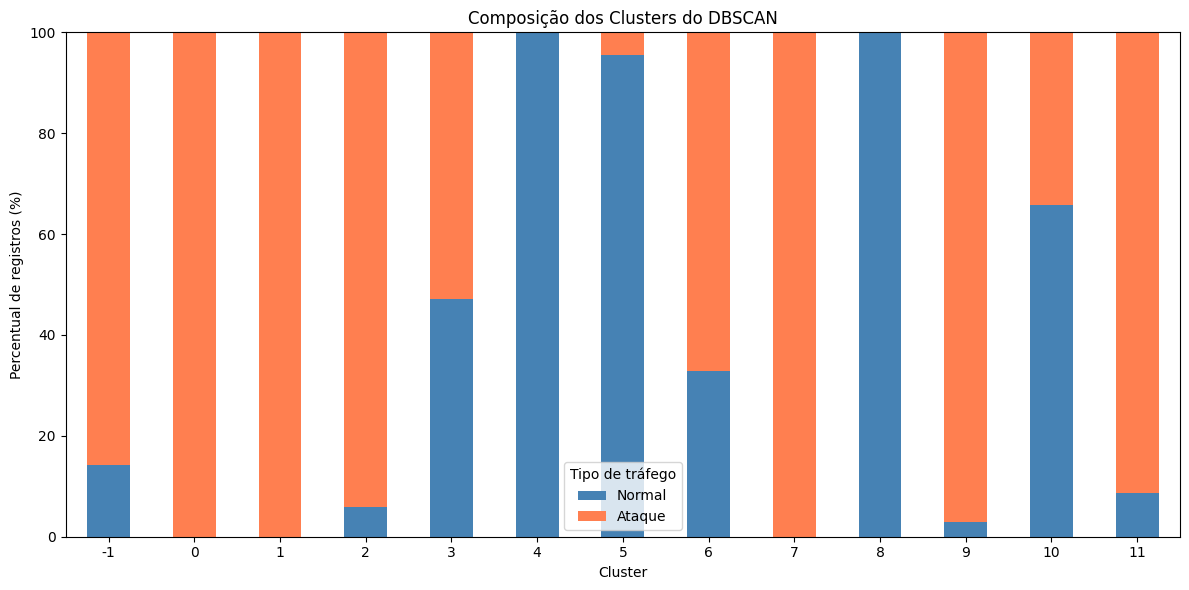

In [49]:

import matplotlib.pyplot as plt

# Percentual de tráfego normal e ataques por cluster
percentuais_clusters = (
    tabela_clusters.div(
        tabela_clusters.sum(axis=1),
        axis=0
    ) * 100
)

# Gráfico de barras empilhadas
ax = percentuais_clusters.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['steelblue', 'coral']
)

plt.title('Composição dos Clusters do DBSCAN')
plt.xlabel('Cluster')
plt.ylabel('Percentual de registros (%)')
plt.legend(
    title='Tipo de tráfego',
    labels=['Normal', 'Ataque']
)

plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


### Interpretação da Visualização dos Clusters

O gráfico de composição dos clusters evidencia diferenças relevantes entre os agrupamentos identificados pelo DBSCAN.

Os clusters 0, 1 e 7 são compostos exclusivamente por registros associados a ataques, enquanto os clusters 4 e 8 apresentam somente tráfego normal. Outros grupos também demonstram predominância expressiva de uma das classes.

Entretanto, foram identificados agrupamentos mistos, como o Cluster 3, no qual a distribuição entre tráfego normal e ataques é relativamente equilibrada.

Os registros classificados como ruído também apresentaram elevada concentração de ataques, correspondendo a aproximadamente 85,82% das observações dessa categoria.

Esses resultados sugerem que o algoritmo identificou estruturas relacionadas a diferentes comportamentos de tráfego de rede, mesmo sem utilizar os rótulos durante a formação dos agrupamentos.

Contudo, a presença de grupos mistos e de registros normais classificados como ruído demonstra que o agrupamento não permite identificar automaticamente todas as atividades maliciosas. Além disso, a análise foi realizada sobre a amostra utilizada no ajuste dos parâmetros, sendo necessária uma avaliação independente para investigar a generalização dos resultados.

### Conclusão da Validação e Ajuste de Hiperparâmetros

A etapa de validação e ajuste de hiperparâmetros permitiu investigar a influência de diferentes configurações sobre os resultados dos algoritmos K-Means, MiniBatch K-Means e DBSCAN.

No K-Means, foram observadas variações na qualidade dos agrupamentos entre diferentes inicializações. A análise de concordância apresentou ARI médio de 0,7976, indicando semelhança relativamente elevada entre parte das soluções, embora uma inicialização tenha produzido agrupamentos distintos. A configuração com cinco clusters e `n_init=10` foi selecionada como candidata para as análises posteriores.

No MiniBatch K-Means, o ajuste do tamanho dos lotes apresentou diferenças pequenas entre as configurações avaliadas. O parâmetro `batch_size=512` obteve o maior Silhouette Score entre os testes realizados, com valor aproximado de 0,2345.

Para o DBSCAN, foram investigadas diferentes combinações de `eps` e `min_samples`. A configuração com `eps=0,5` e `min_samples=20` apresentou o maior Silhouette Score, porém classificou 33,82% dos registros como ruído.

Por outro lado, a configuração com `eps=3,0` e `min_samples=20` apresentou um equilíbrio mais favorável entre separação dos clusters e proporção de registros agrupados, sendo selecionada como candidata principal.

A análise posterior dos rótulos demonstrou que vários clusters apresentaram elevada concentração de tráfego normal ou de ataques cibernéticos, sugerindo a existência de padrões relevantes nos dados.

Entretanto, os resultados obtidos ainda são exploratórios e não representam uma validação independente da capacidade dos modelos de identificar ameaças em novos dados. Dessa forma, a etapa seguinte deverá aprofundar a avaliação quantitativa e investigar a generalização dos agrupamentos encontrados.

# 8. Métricas de Avaliação dos Modelos

Nesta etapa serão utilizadas diferentes métricas para avaliar a qualidade dos agrupamentos produzidos pelos algoritmos K-Means, MiniBatch K-Means e DBSCAN.

Serão consideradas as métricas Silhouette Score, Davies-Bouldin Index e Calinski-Harabasz Index, permitindo analisar diferentes aspectos da coesão, separação e dispersão dos grupos encontrados.

A avaliação será realizada inicialmente utilizando as mesmas observações e a mesma representação dos dados para os três algoritmos.

Como o DBSCAN pode classificar determinados registros como ruído, essa característica será considerada separadamente na interpretação dos resultados.

As métricas internas não utilizam os rótulos de tráfego normal e ataques, preservando a natureza não supervisionada da avaliação.

In [50]:

from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import pandas as pd
import numpy as np

# Mesmos dados para os três algoritmos
X_avaliacao = np.asarray(X_dbscan_pca)

# Configurações selecionadas
modelos_avaliacao = {
    "K-Means": KMeans(
        n_clusters=5,
        n_init=10,
        random_state=42
    ),

    "MiniBatch K-Means": MiniBatchKMeans(
        n_clusters=2,
        batch_size=512,
        n_init=10,
        random_state=42
    ),

    "DBSCAN": DBSCAN(
        eps=3.0,
        min_samples=20,
        n_jobs=-1
    )
}

resultados_metricas = []
rotulos_modelos = {}

for nome, modelo in modelos_avaliacao.items():

    print(f"Avaliando {nome}...")

    clusters = modelo.fit_predict(X_avaliacao)
    rotulos_modelos[nome] = clusters

    # Remover ruído (-1) somente da avaliação interna
    mascara = clusters != -1

    dados_validos = X_avaliacao[mascara]
    clusters_validos = clusters[mascara]

    n_clusters = len(np.unique(clusters_validos))

    percentual_ruido = np.mean(clusters == -1) * 100
    percentual_agrupado = np.mean(mascara) * 100

    if 2 <= n_clusters < len(dados_validos):

        silhouette = silhouette_score(
            dados_validos,
            clusters_validos,
            sample_size=min(2000, len(dados_validos)),
            random_state=42
        )

        davies = davies_bouldin_score(
            dados_validos,
            clusters_validos
        )

        calinski = calinski_harabasz_score(
            dados_validos,
            clusters_validos
        )

    else:
        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    resultados_metricas.append({
        "Algoritmo": nome,
        "Clusters": n_clusters,
        "Silhouette": silhouette,
        "Davies-Bouldin": davies,
        "Calinski-Harabasz": calinski,
        "Agrupados (%)": percentual_agrupado,
        "Ruído (%)": percentual_ruido
    })

metricas_df = pd.DataFrame(resultados_metricas)

print("\n===== AVALIAÇÃO DOS MODELOS =====")
display(metricas_df.round(4))


Avaliando K-Means...
Avaliando MiniBatch K-Means...
Avaliando DBSCAN...

===== AVALIAÇÃO DOS MODELOS =====


,Algoritmo,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,Agrupados (%),Ruído (%)
0,K-Means,5,0.2500,0.9874,260.0447,100.00,0.00
1,MiniBatch K-Means,2,0.2407,1.8307,428.1250,100.00,0.00
2,DBSCAN,12,0.5794,0.4716,1686.7406,89.56,10.44


### Interpretação das Métricas de Avaliação

A avaliação dos algoritmos K-Means, MiniBatch K-Means e DBSCAN foi realizada utilizando as métricas Silhouette Score, Davies-Bouldin Index e Calinski-Harabasz Index.

O K-Means apresentou Silhouette Score de 0,2500, Davies-Bouldin de 0,9874 e Calinski-Harabasz de 260,0447, formando cinco clusters e agrupando todos os registros analisados.

O MiniBatch K-Means obteve Silhouette Score de 0,2407, Davies-Bouldin de 1,8307 e Calinski-Harabasz de 428,1250, formando dois clusters e também atribuindo todos os registros a grupos.

O DBSCAN apresentou Silhouette Score de 0,5794, Davies-Bouldin de 0,4716 e Calinski-Harabasz de 1.686,7406, identificando 12 clusters e classificando 10,44% dos registros como ruído.

Os resultados indicam que o DBSCAN produziu agrupamentos com métricas internas mais favoráveis entre os registros efetivamente agrupados. Entretanto, como os pontos classificados como ruído foram excluídos dessas métricas, os resultados não representam uma comparação inteiramente equivalente entre os algoritmos.

Dessa forma, a avaliação sugere que o DBSCAN é uma alternativa promissora para a identificação de diferentes padrões de tráfego de rede, sendo necessária uma análise complementar utilizando os rótulos conhecidos e uma avaliação independente antes de estabelecer conclusões definitivas.

### 8.7 Avaliação Externa dos Agrupamentos

Além das métricas internas, será realizada uma avaliação externa dos agrupamentos utilizando os rótulos conhecidos do dataset UNSW-NB15.

Serão calculadas as métricas Adjusted Rand Index (ARI) e Adjusted Mutual Information (AMI), buscando investigar a concordância entre os grupos identificados pelos algoritmos e a classificação conhecida de tráfego normal e ataques.

As variáveis de classificação serão utilizadas exclusivamente nesta etapa de avaliação, não participando da formação dos clusters.

O objetivo é verificar se os padrões encontrados pelo aprendizado não supervisionado apresentam associação com os comportamentos previamente identificados no conjunto de dados.

In [51]:

from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score
)

import pandas as pd
import numpy as np

# Rótulos reais correspondentes aos 5.000 registros
labels_reais = df.loc[X_dbscan.index, 'label'].to_numpy()

resultados_externos = []

for nome, clusters in rotulos_modelos.items():

    # Avaliação considerando todos os registros
    # O ruído do DBSCAN (-1) é tratado como um grupo separado
    ari = adjusted_rand_score(
        labels_reais,
        clusters
    )

    ami = adjusted_mutual_info_score(
        labels_reais,
        clusters
    )

    resultados_externos.append({
        'Algoritmo': nome,
        'ARI': ari,
        'AMI': ami
    })

metricas_externas_df = pd.DataFrame(resultados_externos)

print("===== MÉTRICAS EXTERNAS =====")
display(metricas_externas_df.round(4))


===== MÉTRICAS EXTERNAS =====


,Algoritmo,ARI,AMI
0,K-Means,0.0950,0.0742
1,MiniBatch K-Means,0.1086,0.0791
2,DBSCAN,0.0865,0.1794


### Interpretação das Métricas Externas

A avaliação externa dos algoritmos foi realizada utilizando as métricas Adjusted Rand Index (ARI) e Adjusted Mutual Information (AMI), comparando os agrupamentos encontrados com os rótulos conhecidos de tráfego normal e ataques do dataset UNSW-NB15.

O MiniBatch K-Means apresentou o maior ARI, com valor de 0,1086, seguido pelo K-Means, com 0,0950, e pelo DBSCAN, com 0,0865.

Entretanto, os valores de ARI permaneceram relativamente próximos de zero, indicando baixa concordância entre os agrupamentos e a divisão binária conhecida do conjunto de dados.

Em relação ao AMI, o DBSCAN apresentou o maior resultado, alcançando 0,1794, enquanto o MiniBatch K-Means obteve 0,0791 e o K-Means apresentou 0,0742.

Esses resultados indicam que o DBSCAN apresentou maior associação informacional com os rótulos conhecidos segundo o AMI, embora não tenha alcançado o maior ARI.

A diferença entre os resultados internos e externos demonstra que agrupamentos com boa separação matemática não correspondem necessariamente às categorias conhecidas de tráfego normal e ataques.

Isso ocorre porque os algoritmos não supervisionados procuram semelhanças entre características dos registros, podendo identificar diferentes perfis de comunicação dentro de uma mesma classe.

Portanto, os resultados sugerem que os agrupamentos encontrados representam estruturas presentes no tráfego, mas não reproduzem diretamente a classificação binária de ataques. A utilidade prática dos grupos deverá ser investigada por meio de análises complementares.

### 8.10 Avaliação dos Agrupamentos por Categoria de Ataque

Nesta etapa será investigada a relação entre os agrupamentos identificados e as diferentes categorias de ataques presentes no dataset UNSW-NB15.

Diferentemente da avaliação binária, que considera apenas tráfego normal e ataques, esta análise utilizará a variável `attack_cat`, permitindo observar a distribuição dos diferentes tipos de ataques entre os clusters.

O objetivo é verificar se determinados agrupamentos apresentam concentração de categorias específicas e avaliar a capacidade dos algoritmos de representar diferentes perfis de comportamento do tráfego de rede.

As categorias serão utilizadas exclusivamente para avaliação, sem participar do treinamento dos algoritmos.

In [52]:

from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score
)

import pandas as pd

# Categorias reais dos mesmos 5.000 registros
categorias_reais = df.loc[
    X_dbscan.index, 'attack_cat'
].to_numpy()

resultados_categorias = []

for nome, clusters in rotulos_modelos.items():

    ari = adjusted_rand_score(
        categorias_reais,
        clusters
    )

    ami = adjusted_mutual_info_score(
        categorias_reais,
        clusters
    )

    resultados_categorias.append({
        'Algoritmo': nome,
        'ARI por Categoria': ari,
        'AMI por Categoria': ami
    })

categorias_df = pd.DataFrame(resultados_categorias)

print("===== AVALIAÇÃO POR CATEGORIA DE ATAQUE =====")
display(categorias_df.round(4))


===== AVALIAÇÃO POR CATEGORIA DE ATAQUE =====


,Algoritmo,ARI por Categoria,AMI por Categoria
0,K-Means,0.1456,0.1630
1,MiniBatch K-Means,0.1325,0.1572
2,DBSCAN,0.2986,0.3408


### Interpretação da Avaliação por Categoria de Ataque

A avaliação externa por categoria de ataque apresentou resultados superiores aos observados na comparação binária entre tráfego normal e ataques.

O K-Means obteve ARI de 0,1456 e AMI de 0,1630, enquanto o MiniBatch K-Means apresentou ARI de 0,1325 e AMI de 0,1572.

O DBSCAN apresentou os maiores valores entre os algoritmos avaliados, alcançando ARI de 0,2986 e AMI de 0,3408.

Esses resultados sugerem que os agrupamentos identificados pelo DBSCAN apresentam maior correspondência com as categorias conhecidas de ataques presentes no dataset UNSW-NB15.

A diferença em relação à avaliação binária indica que os algoritmos podem estar identificando estruturas relacionadas a comportamentos específicos de tráfego, que não são necessariamente representadas pela divisão entre conexões normais e maliciosas.

Entretanto, os valores obtidos ainda demonstram correspondência limitada entre os agrupamentos e as categorias reais. Além disso, os resultados foram calculados na amostra utilizada durante os experimentos e não representam uma avaliação independente.

Dessa forma, os resultados são considerados promissores para a análise exploratória de perfis de tráfego, mas não comprovam, isoladamente, a capacidade de identificar ou classificar novos ataques cibernéticos.